# Линейные модели в машинном обучении

## Описание:

**Заказчик:** фермер, владелец молочного хозяйства «Вольный луг». Он хочет купить бурёнок, чтобы расширить поголовье стада коров. Для этого он заключил выгодный контракт с ассоциацией пастбищ «ЭкоФерма».

**Цель:** разработать модель машинного обучения, которая поможет фермеру управлять рисками и принимать объективное решение о покупке коров. С помощью моделей нужно отобрать коров по двум критериям:
- Средний удой за год — не менее 6000 килограммов;
- Молоко должно быть вкусным.

**Задачи:** создать две прогнозные модели для отбора бурёнок в поголовье:
- Первая будет прогнозировать возможный удой коровы (целевой признак Удой);
- Вторая — рассчитывать вероятность получить вкусное молоко от коровы (целевой признак Вкус молока).

**Данные:** «ЭкоФерма» готова предоставить подробные данные о своих коровах.

Файл `ferma_main.csv` содержит данные о стаде фермера на текущий момент. Описание данных:
- `id` — уникальный идентификатор коровы.
- `Удой, кг` — масса молока, которую корова даёт в год (в килограммах).
- `ЭКЕ (Энергетическая кормовая единица)` — показатель питательности корма коровы.
- `Сырой протеин, г` — содержание сырого протеина в корме (в граммах).
- `СПО (Сахаро-протеиновое соотношение)` — отношение сахара к протеину в корме коровы.
- `Порода` — порода коровы.
- `Тип пастбища` — ландшафт лугов, на которых паслась корова.
- `Порода папы быка` — порода папы коровы.
- `Жирность,%` — содержание жиров в молоке (в процентах).
- `Белок,%` — содержание белков в молоке (в процентах).
- `Вкус молока` — оценка вкуса по личным критериям фермера, бинарный признак (вкусно, не вкусно).
- `Возраст` — возраст коровы, бинарный признак (менее 2 лет, более 2 лет).

Файл `ferma_dad.csv` хранит имя папы каждой коровы в стаде фермера. Описание данных:
- `id` — уникальный идентификатор коровы.
- `Имя Папы` — имя папы коровы.


Файл `cow_buy.csv` — это данные о коровах «ЭкоФермы», которых фермер хочет изучить перед покупкой. Описание данных:
- `Порода` — порода коровы.
- `Тип пастбища` — ландшафт лугов, на которых паслась корова.
- `Порода папы быка` — порода папы коровы.
- `Имя папы` — имя папы коровы.
- `Текущая жирность,%` — содержание жиров в молоке (в процентах).
- `Текущий уровень белок,%` — содержание белков в молоке (в процентах).
- `Возраст` — возраст коровы, бинарный признак (менее_2_лет, более_2_лет).


## Начало работы

In [1]:
# импорт необходимых библиотек
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    root_mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix
)
import phik
import math




# при выводе датафрейма будут показываться все колонки
pd.set_option('display.max_columns', None)

# установим максимальную длину отображаемых строк
pd.set_option('display.max_colwidth', None)

# включим режим Copy-on-Write (COW)
pd.options.mode.copy_on_write = True

# настроим генератора случайных чисел для разделения данных
RANDOM_STATE = 42

## Загрузка данных

Загрузим основные данные о текущем стаде, в т.ч. имени и отце коровы, а также информацию о коровах 'Экофермы'. Отредактируем названия столбцов. 

---

In [2]:
try:
    df_1 = pd.read_csv('ferma_main.csv', sep = ";")
    
except:
    df_1 = pd.read_csv('https://code.s3.yandex.net//datasets/ferma_main.csv', sep = ";") 

df_1.head()

,id,"Удой, кг",ЭКЕ (Энергетическая кормовая единица),"Сырой протеин, г",СПО (Сахаро-протеиновое соотношение),Порода,Тип пастбища,порода папы_быка,"Жирность,%","Белок,%",Вкус молока,Возраст
0,1,5863,"14,2",1743,"0,89",Вис Бик Айдиал,Равнинное,Айдиал,"3,58","3,076",вкусно,более_2_лет
1,2,5529,"12,8",2138,"0,89",Вис Бик Айдиал,Равнинные,Соверин,"3,54","3,079",вкусно,менее_2_лет
2,3,5810,14,1854,"0,885",РефлешнСоверинг,Холмистое,Соверин,"3,59","3,074",не вкусно,более_2_лет
3,4,5895,"12,4",2012,"0,885",РефлешнСоверинг,Холмистое,Айдиал,"3,4","3,075",не вкусно,более_2_лет
4,5,5302,"12,8",1675,"0,885",Вис Бик Айдиал,Равнинные,Соверин,"3,73","3,073",вкусно,менее_2_лет


In [3]:
df_1.columns = [
    'id',
    'удой_кг',
    'эке',
    'сырой_протеин_г',
    'спо', 
    'порода',
    'тип_пастбища',
    'порода_отца_быка',
    'жирность_%',
    'белок_%',
    'вкус_молока',
    'возраст'
]
df_1.head()

,id,удой_кг,эке,сырой_протеин_г,спо,порода,тип_пастбища,порода_отца_быка,жирность_%,белок_%,вкус_молока,возраст
0,1,5863,"14,2",1743,"0,89",Вис Бик Айдиал,Равнинное,Айдиал,"3,58","3,076",вкусно,более_2_лет
1,2,5529,"12,8",2138,"0,89",Вис Бик Айдиал,Равнинные,Соверин,"3,54","3,079",вкусно,менее_2_лет
2,3,5810,14,1854,"0,885",РефлешнСоверинг,Холмистое,Соверин,"3,59","3,074",не вкусно,более_2_лет
3,4,5895,"12,4",2012,"0,885",РефлешнСоверинг,Холмистое,Айдиал,"3,4","3,075",не вкусно,более_2_лет
4,5,5302,"12,8",1675,"0,885",Вис Бик Айдиал,Равнинные,Соверин,"3,73","3,073",вкусно,менее_2_лет


In [4]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id                634 non-null    int64 
 1   удой_кг           634 non-null    int64 
 2   эке               634 non-null    object
 3   сырой_протеин_г   634 non-null    int64 
 4   спо               634 non-null    object
 5   порода            634 non-null    object
 6   тип_пастбища      634 non-null    object
 7   порода_отца_быка  634 non-null    object
 8   жирность_%        634 non-null    object
 9   белок_%           634 non-null    object
 10  вкус_молока       634 non-null    object
 11  возраст           634 non-null    object
dtypes: int64(3), object(9)
memory usage: 59.6+ KB


---

In [5]:
try:
    df_2 = pd.read_csv('ferma_dad.csv', sep = ";")
    
except:
    df_2 = pd.read_csv('https://code.s3.yandex.net//datasets/ferma_dad.csv', sep = ";") 

df_2.head()

,id,Имя Папы
0,1,Буйный
1,2,Соловчик
2,3,Барин
3,4,Буйный
4,5,Барин


In [6]:
df_2.columns = ['id', 'имя_отца']
df_2.head()

,id,имя_отца
0,1,Буйный
1,2,Соловчик
2,3,Барин
3,4,Буйный
4,5,Барин


In [7]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        629 non-null    int64 
 1   имя_отца  629 non-null    object
dtypes: int64(1), object(1)
memory usage: 10.0+ KB


---

In [8]:
try:
    df_3 = pd.read_csv('cow_buy.csv', sep = ";")
    
except:
    df_3 = pd.read_csv('https://code.s3.yandex.net//datasets/cow_buy.csv', sep = ";") 

df_3.head()

,Порода,Тип пастбища,порода папы_быка,Имя_папы,"Текущая_жирность,%","Текущий_уровень_белок,%",Возраст
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,"3,58","3,076",более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,"3,54","3,081",менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,"3,59","3,074",более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,"3,4","3,061",более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,"3,64","3,074",более_2_лет


In [9]:
df_3.columns = [
    'порода',
    'тип_пастбища',
    'порода_отца_быка',
    'имя_отца',
    'жирность_%', # столбцы "Текущая_жирность,%" и "жирность_%" из df_1 имееют одинаковые данные
    'белок_%', # столбцы "Текущий_уровень_белок,%" и "белок_%" из df_1 имееют одинаковые данные
    'возраст'
]
df_3.head()

,порода,тип_пастбища,порода_отца_быка,имя_отца,жирность_%,белок_%,возраст
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,"3,58","3,076",более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,"3,54","3,081",менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,"3,59","3,074",более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,"3,4","3,061",более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,"3,64","3,074",более_2_лет


In [10]:
df_3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   порода            20 non-null     object
 1   тип_пастбища      20 non-null     object
 2   порода_отца_быка  20 non-null     object
 3   имя_отца          20 non-null     object
 4   жирность_%        20 non-null     object
 5   белок_%           20 non-null     object
 6   возраст           20 non-null     object
dtypes: object(7)
memory usage: 1.2+ KB


После первичного изучения данных сформулируем задачи для предобработки:
- изменить тип данных в столбцах "спо", "эке", "белок", " жирность";
- встречаются запятые, как разделитель, в значениях с плавающей точкой; 
- данные в столбце вкус молока можно закодировать, как "вкусно"- 1, "не вкусно" - 0, аналогично можно закодировать возраст;
- привести данные в стобцах "порода", "тип_пастбища", "порода_отца_быка", "имя_отца" к змеиному регистру;
- пропусков в датафреймах не обнаружно;
- в df_2 строк меньше, чем в df_1;
- df_1 и df_2 следует объединить по id;
- df_3 содержит 20 строк с коровами к покупке, будет тестовой выборкой при обучении модели.

##  Предобработка данных

### Поиск пропусков

In [11]:
df_1.isna().sum()

id                  0
удой_кг             0
эке                 0
сырой_протеин_г     0
спо                 0
порода              0
тип_пастбища        0
порода_отца_быка    0
жирность_%          0
белок_%             0
вкус_молока         0
возраст             0
dtype: int64

In [12]:
df_2.isna().sum()

id          0
имя_отца    0
dtype: int64

In [13]:
df_3.isna().sum()

порода              0
тип_пастбища        0
порода_отца_быка    0
имя_отца            0
жирность_%          0
белок_%             0
возраст             0
dtype: int64

### Изменение типов данных

Напишем функцию, которая изменит тип данных в стобцах `"спо"`, `"эке"`, `"белок"`, `"жирность"` на плавающий. Это произойдет в каждом из двух датафреймов `df_1` и `df_3`, где будет совпадение по названию столбца.

In [14]:
dataframes = {'df_1': df_1,'df_2': df_2, 'df_3': df_3} #  создадим словарь со всеми датафреймами

In [15]:
for i in ["спо", "эке", "белок_%", "жирность_%"]:
    for df_name, df in dataframes.items():
        if i in df.columns:
            df[i] = df[i].astype('str').str.replace(',' , '.')
            df[i] = pd.to_numeric(df[i])
            print(f'Столбец "{i}" в {df_name}: {df[i].dtypes}')

Столбец "спо" в df_1: float64
Столбец "эке" в df_1: float64
Столбец "белок_%" в df_1: float64
Столбец "белок_%" в df_3: float64
Столбец "жирность_%" в df_1: float64
Столбец "жирность_%" в df_3: float64


In [16]:
df_1.head()

,id,удой_кг,эке,сырой_протеин_г,спо,порода,тип_пастбища,порода_отца_быка,жирность_%,белок_%,вкус_молока,возраст
0,1,5863,14.2,1743,0.890,Вис Бик Айдиал,Равнинное,Айдиал,3.58,3.076,вкусно,более_2_лет
1,2,5529,12.8,2138,0.890,Вис Бик Айдиал,Равнинные,Соверин,3.54,3.079,вкусно,менее_2_лет
2,3,5810,14.0,1854,0.885,РефлешнСоверинг,Холмистое,Соверин,3.59,3.074,не вкусно,более_2_лет
3,4,5895,12.4,2012,0.885,РефлешнСоверинг,Холмистое,Айдиал,3.40,3.075,не вкусно,более_2_лет
4,5,5302,12.8,1675,0.885,Вис Бик Айдиал,Равнинные,Соверин,3.73,3.073,вкусно,менее_2_лет


In [17]:
df_3.head()

,порода,тип_пастбища,порода_отца_быка,имя_отца,жирность_%,белок_%,возраст
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет


### Поиск дубликатов

#### Явные

Проверим кол-во строк-дубликатов и удалим их.

In [18]:
for df_name, df in dataframes.items():
    print(f'В {df_name}: {df.duplicated().sum()} строк-дубликатов')

В df_1: 5 строк-дубликатов
В df_2: 0 строк-дубликатов
В df_3: 4 строк-дубликатов


In [19]:
for df_name, df in dataframes.items():
    df.drop_duplicates(inplace=True)
    print(f'В {df_name}: {df.duplicated().sum()} строк-дубликатов')

В df_1: 0 строк-дубликатов
В df_2: 0 строк-дубликатов
В df_3: 0 строк-дубликатов


#### Неявные

In [20]:
for col in ["порода", "тип_пастбища", "порода_отца_быка", "имя_отца", "возраст"]:
    for df_name, df in dataframes.items():
        if col in df.columns:
            df[col] = df[col].str.lower() # приведем значения к нижнему регистру
            print(f'Уникальные значения в столбце "{col}" в {df_name}: {df[col].unique()}')

Уникальные значения в столбце "порода" в df_1: ['вис бик айдиал' 'рефлешнсоверинг']
Уникальные значения в столбце "порода" в df_3: ['вис бик айдиал' 'рефлешнсоверинг']
Уникальные значения в столбце "тип_пастбища" в df_1: ['равнинное' 'равнинные' 'холмистое']
Уникальные значения в столбце "тип_пастбища" в df_3: ['холмистое' 'равнинное']
Уникальные значения в столбце "порода_отца_быка" в df_1: ['айдиал' 'соверин' 'айдиалл']
Уникальные значения в столбце "порода_отца_быка" в df_3: ['айдиал' 'соверин']
Уникальные значения в столбце "имя_отца" в df_2: ['буйный' 'соловчик' 'барин' 'геркулес']
Уникальные значения в столбце "имя_отца" в df_3: ['геркулес' 'буйный' 'барин' 'соловчик']
Уникальные значения в столбце "возраст" в df_1: ['более_2_лет' 'менее_2_лет']
Уникальные значения в столбце "возраст" в df_3: ['более_2_лет' 'менее_2_лет']


В столбцах "тип_пастбища" и "порода_отца_быка" в двух датафреймах встречаются разные уникальные значения. Исправим в df_1.

In [21]:
changes = {
    'вис бик ' : '', # 'вис бик айдиал' в 'айдиал'
    'айдиалл': 'айдиал',
    'рефлешн' : '', # 'рефлешнсоверинг' в 'соверинг'
    'г' : '', # 'соверинг' в 'соверин'
    'равнинные': 'равнинное'
}


for col in ["порода_отца_быка", "порода", "тип_пастбища"]:
    for df_name, df in dataframes.items():
        if col in df.columns:
            for old, new in changes.items():
                df[col] = df[col].str.replace(old, new)
            print(f'Уникальные значения в столбце "{col}" в {df_name}: {df[col].unique()}')

Уникальные значения в столбце "порода_отца_быка" в df_1: ['айдиал' 'соверин']
Уникальные значения в столбце "порода_отца_быка" в df_3: ['айдиал' 'соверин']
Уникальные значения в столбце "порода" в df_1: ['айдиал' 'соверин']
Уникальные значения в столбце "порода" в df_3: ['айдиал' 'соверин']
Уникальные значения в столбце "тип_пастбища" в df_1: ['равнинное' 'холмистое']
Уникальные значения в столбце "тип_пастбища" в df_3: ['холмистое' 'равнинное']


### Объединение датафреймов

Объединим данные из `df_1` и `df_2` методом `merge`. Проверим размеры этих датасетов.

In [22]:
print(df_1.shape)
print(df_2.shape)

(629, 12)
(629, 2)


In [23]:
df_ferma = df_1.merge(df_2, on='id') 
df_ferma

,id,удой_кг,эке,сырой_протеин_г,спо,порода,тип_пастбища,порода_отца_быка,жирность_%,белок_%,вкус_молока,возраст,имя_отца
0,1,5863,14.2,1743,0.890,айдиал,равнинное,айдиал,3.58,3.076,вкусно,более_2_лет,буйный
1,2,5529,12.8,2138,0.890,айдиал,равнинное,соверин,3.54,3.079,вкусно,менее_2_лет,соловчик
2,3,5810,14.0,1854,0.885,соверин,холмистое,соверин,3.59,3.074,не вкусно,более_2_лет,барин
3,4,5895,12.4,2012,0.885,соверин,холмистое,айдиал,3.40,3.075,не вкусно,более_2_лет,буйный
4,5,5302,12.8,1675,0.885,айдиал,равнинное,соверин,3.73,3.073,вкусно,менее_2_лет,барин
...,...,...,...,...,...,...,...,...,...,...,...,...,...
624,625,6812,15.4,1964,0.940,соверин,равнинное,айдиал,3.74,3.075,не вкусно,более_2_лет,буйный
625,626,5513,12.9,1700,0.880,соверин,равнинное,соверин,3.64,3.073,вкусно,менее_2_лет,барин
626,627,5970,14.4,1837,0.880,соверин,холмистое,соверин,3.64,3.075,не вкусно,более_2_лет,барин
627,628,5746,13.8,1994,0.890,соверин,равнинное,соверин,3.64,3.077,вкусно,более_2_лет,барин


In [24]:
df_ferma.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                629 non-null    int64  
 1   удой_кг           629 non-null    int64  
 2   эке               629 non-null    float64
 3   сырой_протеин_г   629 non-null    int64  
 4   спо               629 non-null    float64
 5   порода            629 non-null    object 
 6   тип_пастбища      629 non-null    object 
 7   порода_отца_быка  629 non-null    object 
 8   жирность_%        629 non-null    float64
 9   белок_%           629 non-null    float64
 10  вкус_молока       629 non-null    object 
 11  возраст           629 non-null    object 
 12  имя_отца          629 non-null    object 
dtypes: float64(4), int64(3), object(6)
memory usage: 64.0+ KB


Также проверим обработанные данные в `df_3`.

In [25]:
df_3

,порода,тип_пастбища,порода_отца_быка,имя_отца,жирность_%,белок_%,возраст
0,айдиал,холмистое,айдиал,геркулес,3.58,3.076,более_2_лет
1,айдиал,равнинное,соверин,буйный,3.54,3.081,менее_2_лет
2,соверин,равнинное,соверин,барин,3.59,3.074,более_2_лет
3,соверин,холмистое,айдиал,буйный,3.40,3.061,более_2_лет
4,соверин,равнинное,айдиал,буйный,3.64,3.074,более_2_лет
5,соверин,равнинное,соверин,геркулес,3.63,3.053,менее_2_лет
7,айдиал,равнинное,соверин,буйный,3.57,3.079,более_2_лет
9,соверин,холмистое,айдиал,буйный,3.40,3.079,менее_2_лет
10,айдиал,холмистое,соверин,соловчик,3.73,3.055,более_2_лет
11,соверин,равнинное,соверин,геркулес,3.73,3.073,более_2_лет


In [26]:
df_3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16 entries, 0 to 18
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   порода            16 non-null     object 
 1   тип_пастбища      16 non-null     object 
 2   порода_отца_быка  16 non-null     object 
 3   имя_отца          16 non-null     object 
 4   жирность_%        16 non-null     float64
 5   белок_%           16 non-null     float64
 6   возраст           16 non-null     object 
dtypes: float64(2), object(5)
memory usage: 1.0+ KB


Сделаем ресет индексов:

In [27]:
df_3 = df_3.reset_index(drop=True)
df_ferma = df_ferma.reset_index(drop=True)

Предобработка выполнена:
- названия столбцов изменены,
- все значения имеют змеиный регистр,
- убраны все явные и неявные дубликаты,
- пропусков не обнаружено,
- изменены типы данных в некоторых столбцах;
- обновлены индексы.

## Исследовательский анализ данных

### Числовые признаки

Выведем основную информацию о столбцах с числовыми значениями методом `describe`. С ее помощью в дальнейшем будем подбирать значения в парметре `bins` -  кол-ва корзин для построения гистограмм.

In [28]:
df_ferma.describe()

,id,удой_кг,эке,сырой_протеин_г,спо,жирность_%,белок_%
count,629.00000,629.000000,629.000000,629.000000,629.000000,629.000000,629.000000
mean,315.00000,6188.750397,14.543879,1923.364070,0.913116,3.603657,3.075671
std,181.72094,1644.795489,1.306408,182.956251,0.032203,0.168656,0.002549
min,1.00000,5204.000000,10.900000,1660.000000,0.840000,2.990000,3.069000
25%,158.00000,5751.000000,13.500000,1771.000000,0.890000,3.590000,3.074000
50%,315.00000,6133.000000,14.700000,1888.000000,0.930000,3.650000,3.076000
75%,472.00000,6501.000000,15.600000,2062.000000,0.940000,3.720000,3.077000
max,629.00000,45616.000000,16.800000,2349.000000,0.960000,3.750000,3.085000


Создадим функцию для построения боксплота и гистограммы для нужно числового признака. Используем библиотеку `seaborn`.

In [29]:
def show_box_hist_plots (
    col,
    bins = 100,
    title = 'Распределение значений',
    xlabel = None
):
    
    fig, ax = plt.subplots(2, sharex = True, gridspec_kw={"height_ratios": (.15, .85)})
    sns.histplot(x = col, ax = ax[1], bins = bins, color = '#800000')
    sns.boxplot(x = col, ax = ax[0], orient = 'h', color = '#800000')
    ax[0].set(title = title)
    ax[1].set(ylabel = 'Количество значений, шт', xlabel = xlabel)
    plt.show()

    print(f'Среднее: {col.mean()}')
    print(f'Медиана: {col.median()}')
    print(f'Мода: {col.mode()[0]}')
    print(f'Стандартное отклонение: {col.std()}')

#### Удой коров

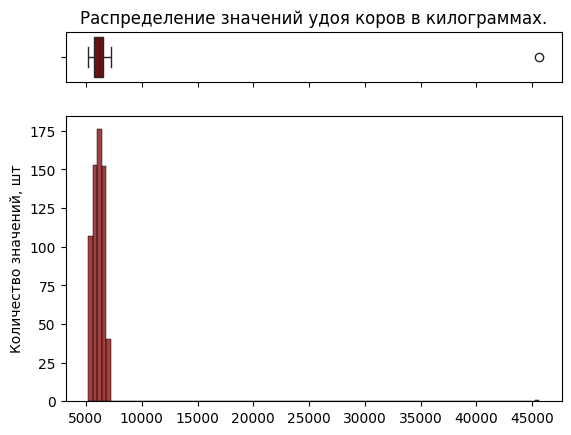

Среднее: 6188.75039745628
Медиана: 6133.0
Мода: 6248
Стандартное отклонение: 1644.7954889098573


In [30]:
show_box_hist_plots(col = df_ferma['удой_кг'],
                    title = 'Распределение значений удоя коров в килограммах.')

На графиках есть значение удоя более 45000 кг. Такого быть не может, это аномалия. Отобразим 5 самых больших значений.

In [31]:
df_ferma['удой_кг'].sort_values().tail()

294     7197
296     7201
135     7207
70      7222
16     45616
Name: удой_кг, dtype: int64

Удалим строку из датафрейма с индексом 16.

In [32]:
df_ferma = df_ferma[df_ferma.index != 16]

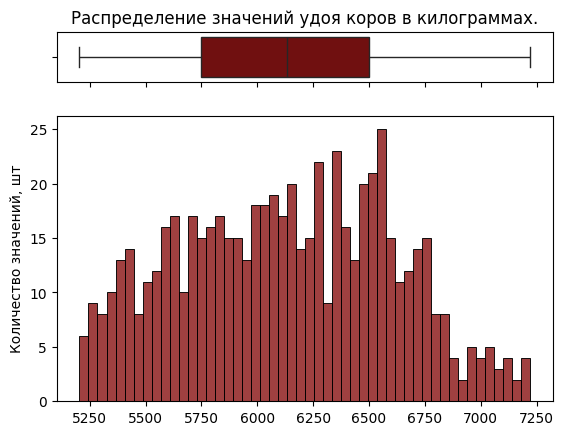

Среднее: 6125.968152866242
Медиана: 6132.5
Мода: 6248
Стандартное отклонение: 475.85705331358616


In [33]:
show_box_hist_plots(col = df_ferma['удой_кг'],
                    title = 'Распределение значений удоя коров в килограммах.',
                    bins = 50)

Распределение стало похожим на равномерное в промежутке от 5300 до 6750. Это первый целевой признак, взаисосвязи с другими будем выяснять в корреляционном анализе. 

#### Энергетическая кормовая единица 

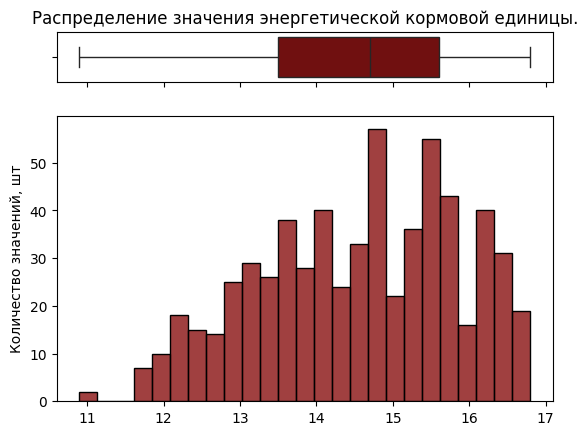

Среднее: 14.548726114649678
Медиана: 14.7
Мода: 14.7
Стандартное отклонение: 1.301777083063757


In [34]:
show_box_hist_plots(col = df_ferma['эке'],
                    title = 'Распределение значения энергетической кормовой единицы.',
                    bins = 25
                   )

Распределение имеет скошенную влево форму, подозрений не вызывает, выбросов не обнаружено.

#### Сырой протеин

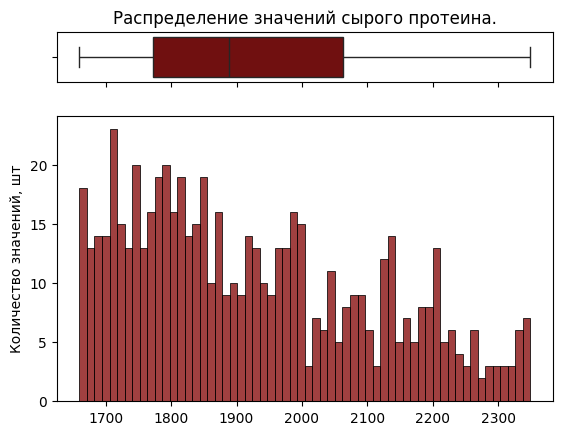

Среднее: 1923.7595541401274
Медиана: 1888.0
Мода: 1712
Стандартное отклонение: 182.83281550454566


In [35]:
show_box_hist_plots(col = df_ferma['сырой_протеин_г'],
                    title = 'Распределение значений сырого протеина.',
                    bins = 60)

Распределение скошено вправо, это также показывает большее значение среднего относительно медианы. По мере увеличения массы протеина, частота снижается.

#### Сахаро-протеиновое соотношение

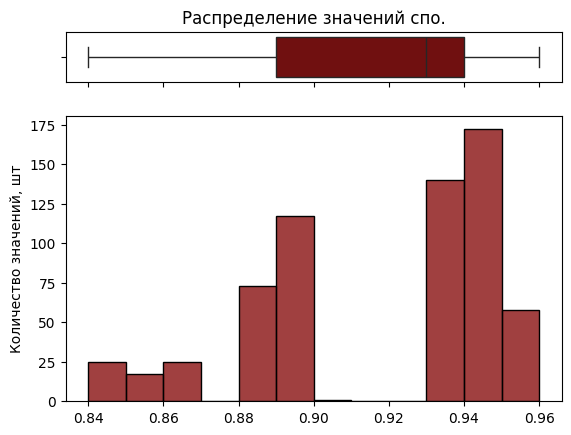

Среднее: 0.9130891719745222
Медиана: 0.93
Мода: 0.94
Стандартное отклонение: 0.03222124984506393


In [36]:
show_box_hist_plots(col = df_ferma['спо'],
                    title = 'Распределение значений спо.',
                    bins = 12)

Некоторые значения отсутвуют, ошибками это не назвать, скорее особенность данных.

#### Жирность молока

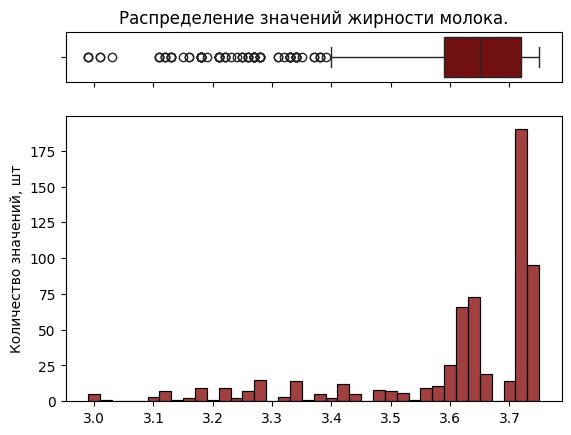

Среднее: 3.604267515923566
Медиана: 3.65
Мода: 3.72
Стандартное отклонение: 0.16809260689673733


In [37]:
show_box_hist_plots(col = df_ferma['жирность_%'],
                    title = 'Распределение значений жирности молока.',
                    bins = 38)

На графике видны выбросы, удалять эти значения не будем. Изучим показатель вкуса молока при сниженном проценте жира (меньше среднего - 3.6%).

In [38]:
df_ferma[df_ferma["жирность_%"] < 3.6].groupby('вкус_молока')["жирность_%"].count()

вкус_молока
вкусно       91
не вкусно    80
Name: жирность_%, dtype: int64

Сниженная жирность прямо не влияет на вкус молока, тк значения разделились примерно равномерно по двум группам. Оставим эти значения.

#### Содержание белка в молоке

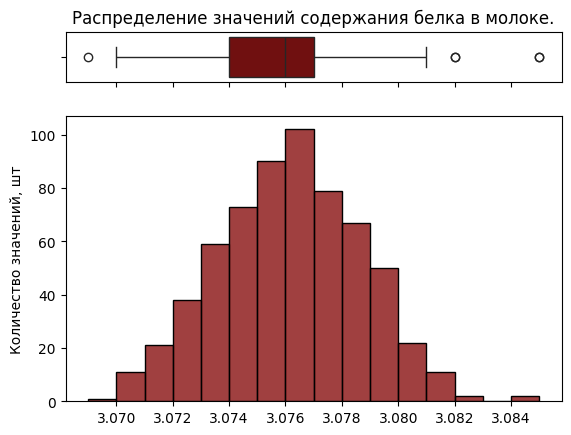

Среднее: 3.0756703821656055
Медиана: 3.076
Мода: 3.076
Стандартное отклонение: 0.002551157321975211


In [39]:
show_box_hist_plots(col = df_ferma['белок_%'],
                    title = 'Распределение значений содержания белка в молоке.',
                    bins = 16)

Среднее, мода и медиана лежат в одной точке 3.076, кажется что распределение нормальное. Надстроим распределение Гаусса и проверим, сходятся ли его точки с гистограмой.

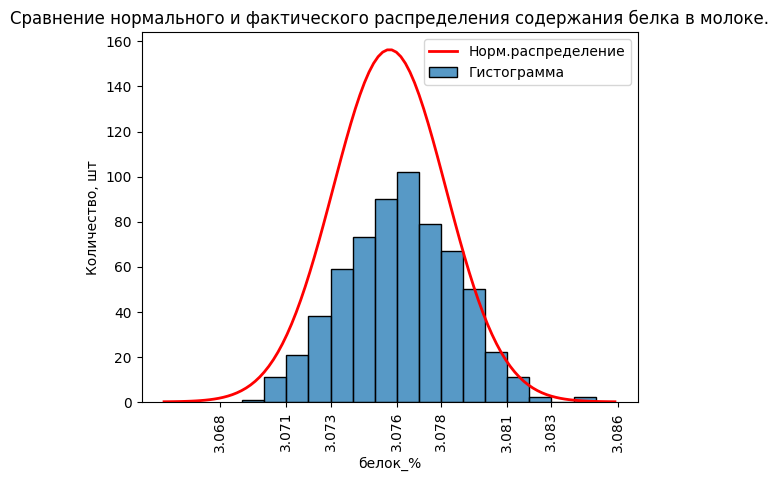

In [40]:
mu = df_ferma['белок_%'].mean()
sigma = df_ferma['белок_%'].std()

left = mu - 4 * sigma # левая граница 
right = mu + 4 * sigma # правая граница 

# зададим функцию, которая выдаёт <num> чисел, равномерно распределённых от <start> до <stop>
def linspace (start, stop, num):
    step = (stop - start) / (num - 1)
    result = []
    for i in range (num):
        result.append(start + step * i)
    return result

x = linspace(left, right, 100) # получим значения для нормального распределения

ax = plt.subplot()
ax.plot(x, norm.pdf(x, mu, sigma), 'r-', lw=2, label= 'Норм.распределение') # строим нормальное распределение
plt.xticks(np.arange(mu - 3 * sigma, mu + 3 * sigma + sigma, sigma).round(3), rotation=90) # укажем только подписи +- 3 сигмы на оси х
sns.histplot(x = df_ferma['белок_%'], ax=ax, bins = 16, label = 'Гистограмма') # строим гистограмму
plt.legend(loc = 'upper right')
plt.ylabel('Количество, шт')
plt.title('Сравнение нормального и фактического распределения содержания белка в молоке.')
plt.show()

Действително, распределение близко к нормальному, но им не является. Выбросы показанные на боксплоте - оставим.

### Категориальные признаки

Аналогично числовым признакам создадим функцию для категориальных, она будет строить столбчатую и круговую диаграммы.

In [41]:
def show_barplot_pie (col, title = 'Диаграмма'):
    fig, ax = plt.subplots(1, 2, figsize=(8,4))
    
    colors = sns.color_palette("Set2", len(col.value_counts()))
    
    sns.barplot(
        x=col.value_counts().index,
        hue=col.value_counts().index,
        y=col.value_counts().values,
        ax = ax[0],
        palette = colors
    )
    
    ax[0].set(ylabel = 'Количество значений, шт', xlabel = None)
    for index, value in enumerate(col.value_counts()):
        ax[0].text(index, 40, str(value), ha='center', fontsize = 16, color = '#ffffff')
    
    ax[1].pie(
        col.value_counts(),
        labels = col.value_counts().index,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors
    )
    ax[0].set_title('Столбчатая диаграмма', fontsize=12)
    ax[1].set_title('Круговая диаграмма', fontsize=12)
    fig.suptitle(title, fontsize=16)
    plt.subplots_adjust(top=0.8)
    plt.show()

#### Порода

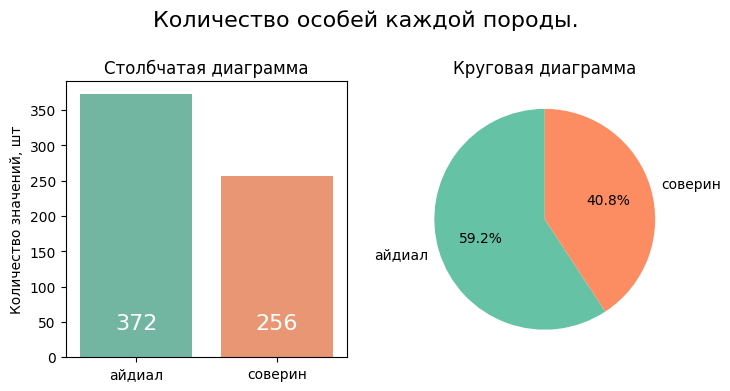

In [42]:
show_barplot_pie(df_ferma['порода'], 
             title = 'Количество особей каждой породы.')

В стаде фермера порода `айдиал` встречается в 1.5 раза чаще, чем порода `соверин`.

#### Тип пастбища

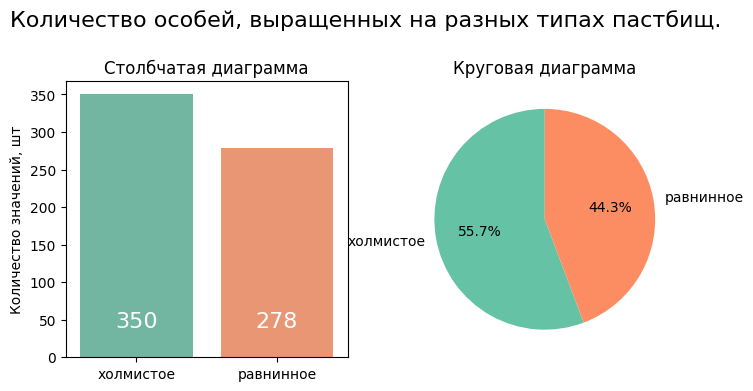

In [43]:
show_barplot_pie(df_ferma['тип_пастбища'], 
             title = 'Количество особей, выращенных на разных типах пастбищ.')

Коров чаще выращивали на холмистых пастбищах. 

#### Вкус молока

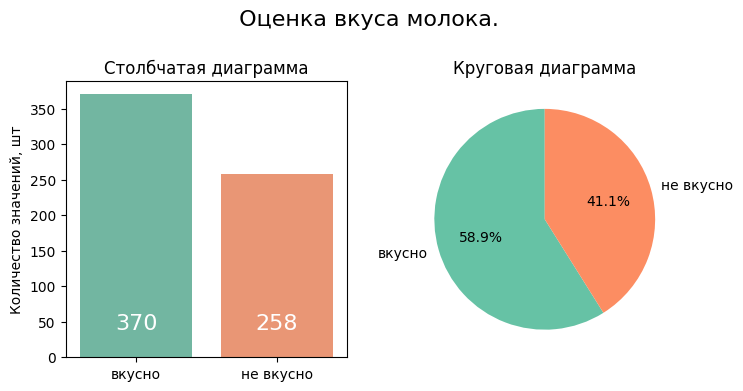

In [44]:
show_barplot_pie(df_ferma['вкус_молока'], 
             title = ' Оценка вкуса молока.')

Процент коров со вкусным молоком из всего стада - 58.9%. Это второй целевой признак, зависимости от других будем изучать в корреляционном анализе.

#### Возраст

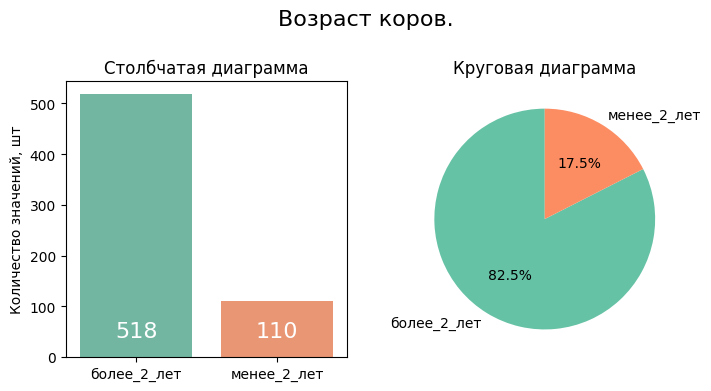

In [45]:
show_barplot_pie(df_ferma['возраст'], 
             title = 'Возраст коров.')

Более 80% стада - коровы старше 2 лет.

#### Имя и порода отца

Выведем имя и породу отца быка в отдельном датафрейме, посчитаем кол-во втречаемости.

In [46]:
name_count = df_ferma.groupby(['имя_отца', 'порода_отца_быка']).size().reset_index(name='кол-во')
name_count

,имя_отца,порода_отца_быка,кол-во
0,барин,айдиал,28
1,барин,соверин,212
2,буйный,айдиал,214
3,геркулес,айдиал,64
4,соловчик,айдиал,11
5,соловчик,соверин,99


Один отец не может быть разной породы. Это ошибка в данных. Исправим породу на ту, которая чаще встречается.

In [47]:
df_ferma.loc[df_ferma['имя_отца'].isin(['барин', 'соловчик']), 'порода_отца_быка'] = 'соверин'

In [48]:
name_count = (
    df_ferma.groupby(['имя_отца', 'порода_отца_быка']).size()
    .reset_index(name='кол-во')
    .sort_values(by='кол-во', ascending = False)
)
name_count

,имя_отца,порода_отца_быка,кол-во
0,барин,соверин,240
1,буйный,айдиал,214
3,соловчик,соверин,110
2,геркулес,айдиал,64


Построим график для `df_ferma`. Данные везьмем из подготовленной выше сводной таблицы. Цвет определяет породу отца-быка.

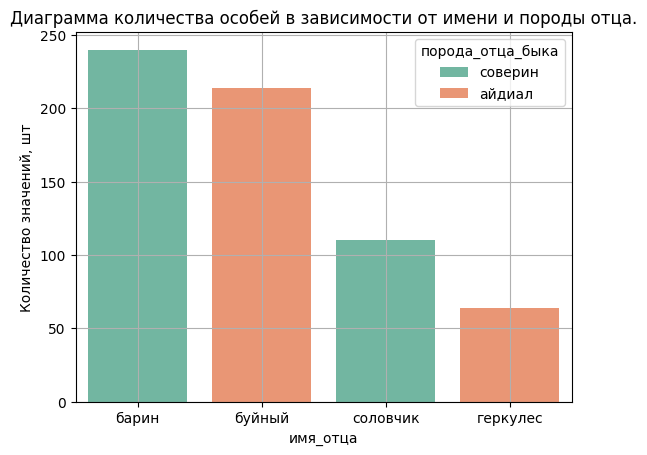

In [49]:
ax = plt.subplot()
colors = sns.color_palette("Set2", len(df_ferma['порода_отца_быка'].value_counts()))
sns.barplot(
    data = name_count,
    ax = ax,
    x = 'имя_отца',
    y = 'кол-во',
    hue = 'порода_отца_быка',
    palette = colors
)
plt.grid(True)
ax.set(
    title = 'Диаграмма количества особей в зависимости от имени и породы отца.', 
    ylabel = 'Количество значений, шт')
plt.show()

Используем функцию и построим стобчатую и круговую диаграмму для особей, чьи отцы отличаются породами.

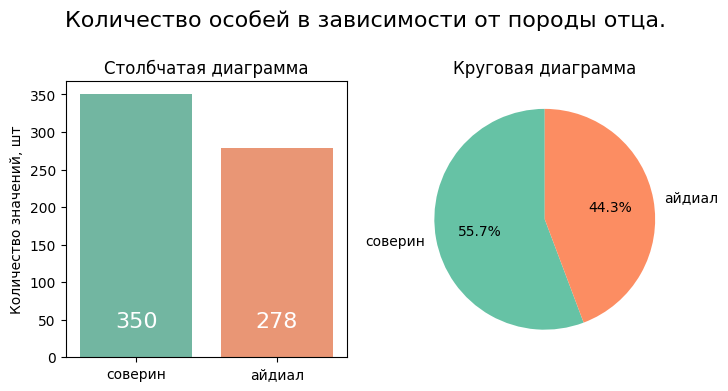

In [50]:
show_barplot_pie(df_ferma['порода_отца_быка'], 
             title = 'Количество особей в зависимости от породы отца.')

Диаграммы дублируют информацию, выведенную шагом ранее, однако тут показана сумма по породе, без разделения на имя быка-отца. Интересно, что соотношение значений, получились тем же самым, что и в признаке `вкус_молока`. Посмотрим, есть ли зависимость.

In [51]:
df_ferma.groupby(['вкус_молока','порода_отца_быка']).size().reset_index(name='кол-во')

,вкус_молока,порода_отца_быка,кол-во
0,вкусно,айдиал,162
1,вкусно,соверин,208
2,не вкусно,айдиал,116
3,не вкусно,соверин,142


Нет, `вкусное` и `невкусное` молоко встречается, как у породы `айдиал`, так и `соверинг`.

---

Проверим правильность породы и имени отца быка в `df_3`.

In [52]:
df_3.groupby(['имя_отца', 'порода_отца_быка']).size().reset_index(name='кол-во')

,имя_отца,порода_отца_быка,кол-во
0,барин,соверин,2
1,буйный,айдиал,4
2,буйный,соверин,3
3,геркулес,айдиал,2
4,геркулес,соверин,3
5,соловчик,соверин,2


В данных также была найдена ошибка, исправим, опираясь на полученный выше датафрем.

In [53]:
df_3.loc[df_3['имя_отца'].isin(['буйный', 'геркулес']), 'порода_отца_быка'] = 'айдиал'

In [54]:
df_3.groupby(['имя_отца', 'порода_отца_быка']).size().reset_index(name='кол-во')

,имя_отца,порода_отца_быка,кол-во
0,барин,соверин,2
1,буйный,айдиал,7
2,геркулес,айдиал,5
3,соловчик,соверин,2


### Вывод

Были рассмотрены все категориальные и количественные признаки, среди них были обнаружены аномалии и ошибки:
1. Удой_кг - целевой признак, удалена аномалия, распределение равномерное на промежутке 5300 - 6750;
2. Энергетическая кормовая единица - данные и распределение в норме;
3. Сырой протеин - данные и распределение в норме;
4. Сахаро-протеиновое соотношение - в некоторых диапазонах значения отсутвуют (0.87 и 0.90-0.93);
5. Жирность молока - показано большое кол-во выбросов (170 шт), однако целевой признак (вкус молока) распределен среди них равномерно, значения удалять не стали;
6. Содержание белка в молоке - распреление близко к нормальному, выбросы не значительны;
7. Порода -  сотношение особей с породами соверин к айдиал - 3:2;
8. Тип пастбища - коров чаще выращивали на холмистых пастбищах;
9. Вкус молока - целевой признак, вкусное молоко у 58.9% коров в стаде;
10. Возраст - более 80% особей старше 2 лет;
11. Имя отца быка - всего 4 варианта отцов, `барин` и `буйный` чаще всего ими становились;
12. Породы отцов - исправлены ошибки в данных, также отредактирована тестовая выборка df_3. Выявили такой же распределение, как и в признаке `вкус молока`, однако зависимостей не обнаружено.

## Корреляционный анализ

### Изучение влияния количественных признаков

Изучим взаимосвязи количественных признаков. Для этого построим тепловую карту корреляционной матрицы, в основе лежит кэффициент Пирсона, он определяет линейную зависимость.

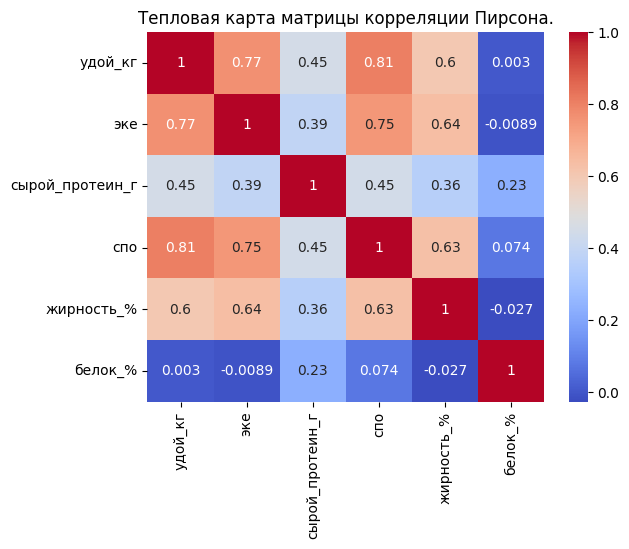

In [55]:
sns.heatmap(
    df_ferma[["удой_кг", "эке", "сырой_протеин_г", "спо", "жирность_%", "белок_%"]].corr(),
    annot = True,
    cmap='coolwarm',
)
plt.title('Тепловая карта матрицы корреляции Пирсона.')
plt.show()

Нас интересует взимосвязь первого целевого признака - удой коров в год. Видим, что корреляция есть у 4 признаков:
- Сахаро-протеиновое соотношение - Коэффициент корреляции пирсона: 0.81
- Энергетическая кормовая единица - Коэффициент корреляции пирсона: 0.77
- Жирность молока - Коэффициент корреляции пирсона: 0.6
- Сырой протеин - Коэффициент корреляции пирсона: 0.45
- Содержание белка - имеет нулевую линейную засимость, либо связь между признаками отсутвует, либо она нелинейна.

Замечена мультиколлинеарность между следующими признаками:
- Сахаро-протеиновое соотношение
- Энергетическая кормовая единица

В этой паре признаков коффициент корреляции Пирсона - 0.75. Это логично, ведь энергетическая кормовая единица корма, должна зависеть от содержания углеводов в нем. Показатель СПО как раз показывает это относительно содержания протеина.

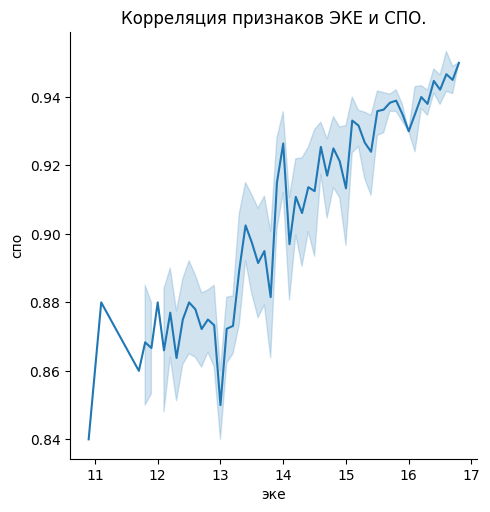

In [56]:
sns.relplot(data=df_ferma, x="эке", y="спо", kind="line")
plt.title('Корреляция признаков ЭКЕ и СПО.')
plt.show()

---

Создадим функцию, благодаря которой можно построить сразу 6 диаграмм рассеяния для каждого категориального признака.

In [57]:
def show_scatterplot(df, x_col, y_col, title):
    _, ax = plt.subplots(3, 2, figsize = (8, 8))
    sns.scatterplot(data = df, x = x_col, y = y_col, hue = 'порода', ax = ax[0, 0])
    sns.scatterplot(data = df, x = x_col, y = y_col, hue = 'тип_пастбища', ax = ax[0, 1])
    sns.scatterplot(data = df, x = x_col, y = y_col, hue = 'возраст', ax = ax[1, 0])
    sns.scatterplot(data = df, x = x_col, y = y_col, hue = 'вкус_молока', ax = ax[1, 1])
    sns.scatterplot(data = df, x = x_col, y = y_col, hue = 'порода_отца_быка', ax = ax[2, 0])
    sns.scatterplot(data = df, x = x_col, y = y_col, hue = 'имя_отца', ax = ax[2,1])
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

---

**Энергетическая кормовая единица.**

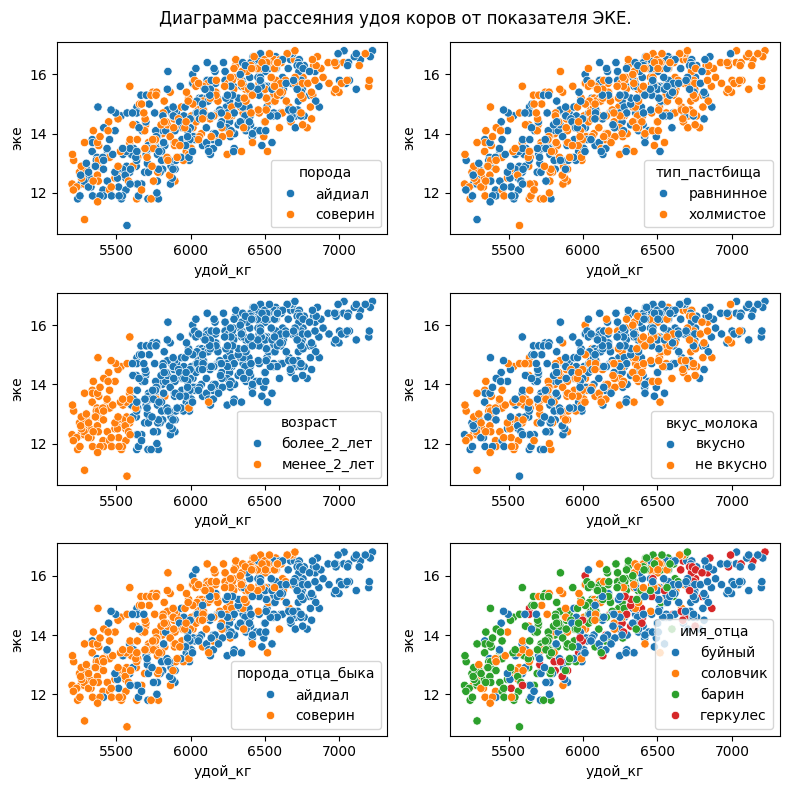

In [58]:
show_scatterplot(
    df = df_ferma,
    x_col = "удой_кг",
    y_col = "эке",
    title = 'Диаграмма рассеяния удоя коров от показателя ЭКЕ.'
)

Коэффициент Пирсона показал выскую положительную корреляцию, что заметно на графиках. Однако форма распределения не в виде прямой.

In [59]:
df_ferma['эке_2'] = np.power(df_ferma['эке'], 2)

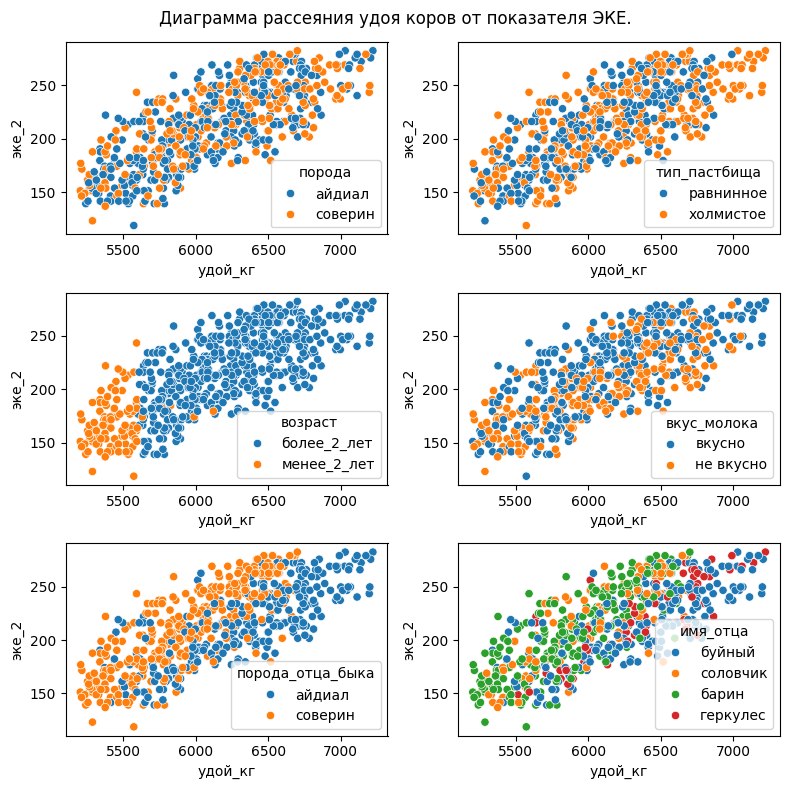

In [60]:
show_scatterplot(
    df = df_ferma,
    x_col = "удой_кг",
    y_col = "эке_2",
    title = 'Диаграмма рассеяния удоя коров от показателя ЭКЕ.'
)

---

**Сахаро-протеиновое соотношение.**

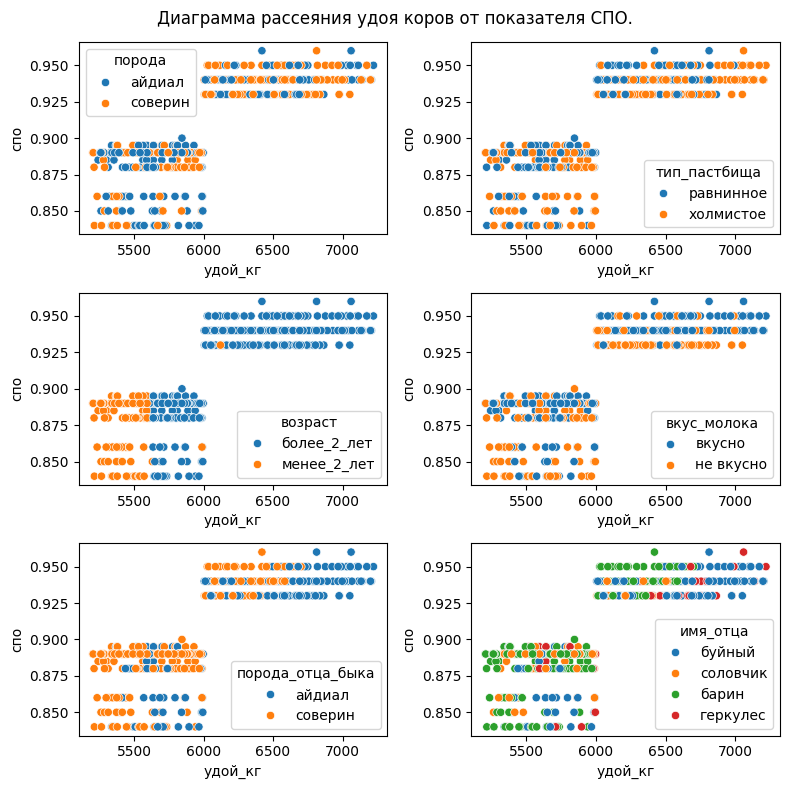

In [61]:
show_scatterplot(
    df = df_ferma,
    x_col = "удой_кг",
    y_col = "спо",
    title = 'Диаграмма рассеяния удоя коров от показателя СПО.'
)

Ввиду отсутствия значений в некоторых диапазонах, что было показано в исследовательском анализе, расспределение кластеризовалось. Коэффициент корреляции Пирсона пары (удой, спо) составил 0.81. Начиная от значения спо в 0.925 и выше удой коровы становится не менее 6000 кг. Для устаранения нелинейности правильно преобразовать признак в категориальный, путем обозначения порога в 0.925 у.е.

In [62]:
df_ferma['спо_кат'] = np.where(df_ferma['спо'] < 0.925, 0, 1)
df_ferma['спо_кат'].astype('str')

0      0
1      0
2      0
3      0
4      0
      ..
624    1
625    0
626    0
627    0
628    1
Name: спо_кат, Length: 628, dtype: object

---

**Жирность молока.**

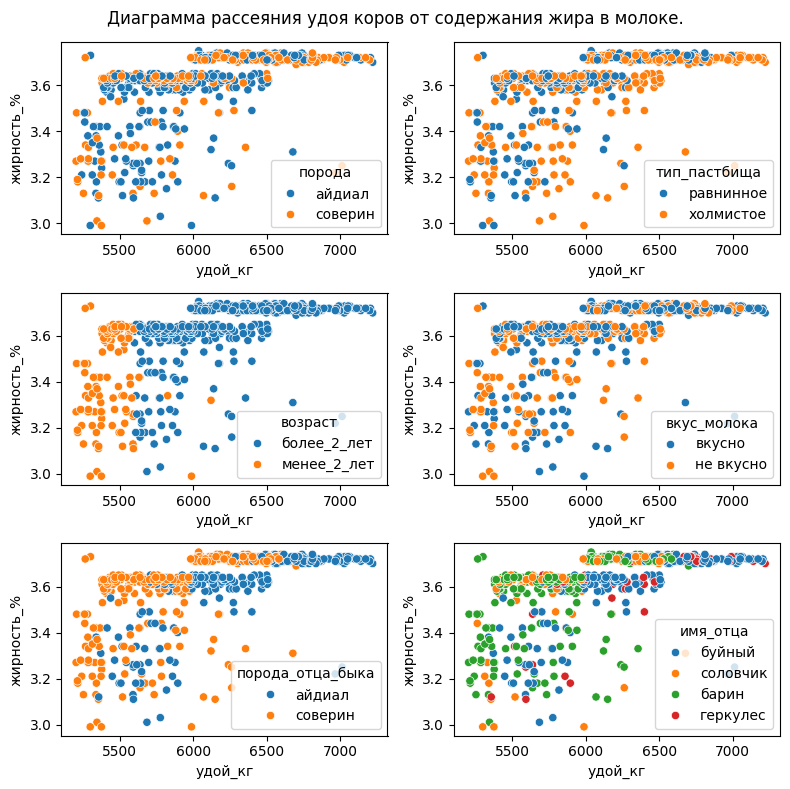

In [63]:
show_scatterplot(
    df = df_ferma,
    x_col = "удой_кг",
    y_col = "жирность_%",
    title = 'Диаграмма рассеяния удоя коров от содержания жира в молоке.'
)

Жирность молока тоже влияет на значение удоя коровы. Коэффициент корреляции Пирсона - 0.6, что указывает на среднюю взаимосвязь. Из-за неоднородности значений происходит кластеризация и появляется нелиненая связь.

In [64]:
print(f"Процент коров с удоем не менее 6000 кг в год при жирности молока более 3.5% составляет: {(df_ferma.query('`жирность_%` > 3.5 and удой_кг >= 6000')['удой_кг'].count()/df_ferma.query('`жирность_%` > 3.5')['удой_кг'].count()*100):.0f}%")

Процент коров с удоем не менее 6000 кг в год при жирности молока более 3.5% составляет: 70%


---

**Сырой протеин.**

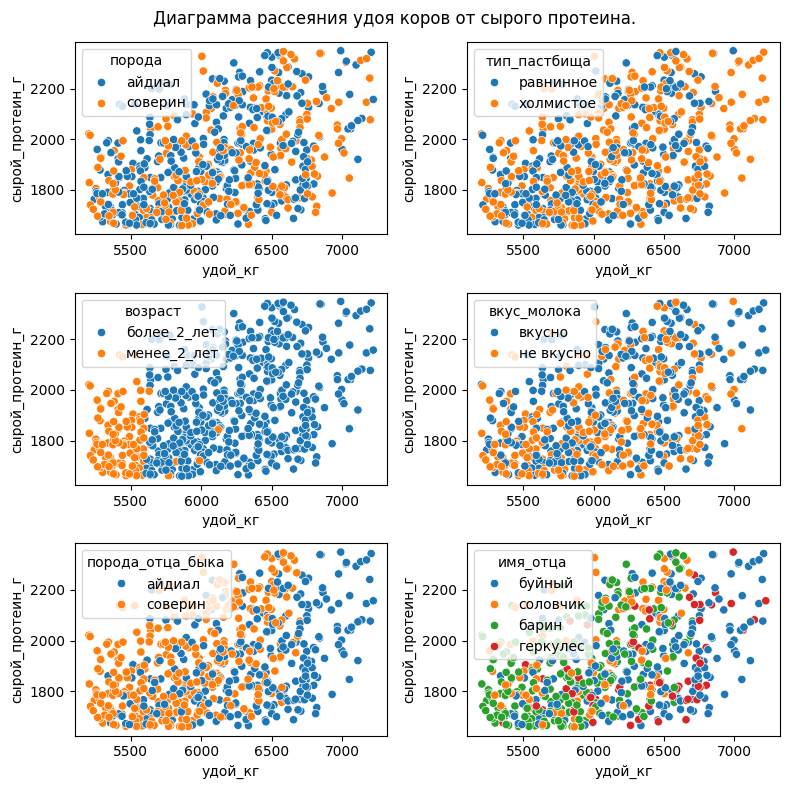

In [65]:
show_scatterplot(
    df = df_ferma,
    x_col = "удой_кг",
    y_col = "сырой_протеин_г",
    title = 'Диаграмма рассеяния удоя коров от сырого протеина.'
)

Показатель сырого протеина слабо влияет на удой, это подтверждает низкий коэффициент корреляции Пирсона - 0.41.

---

**Содержание белка.**

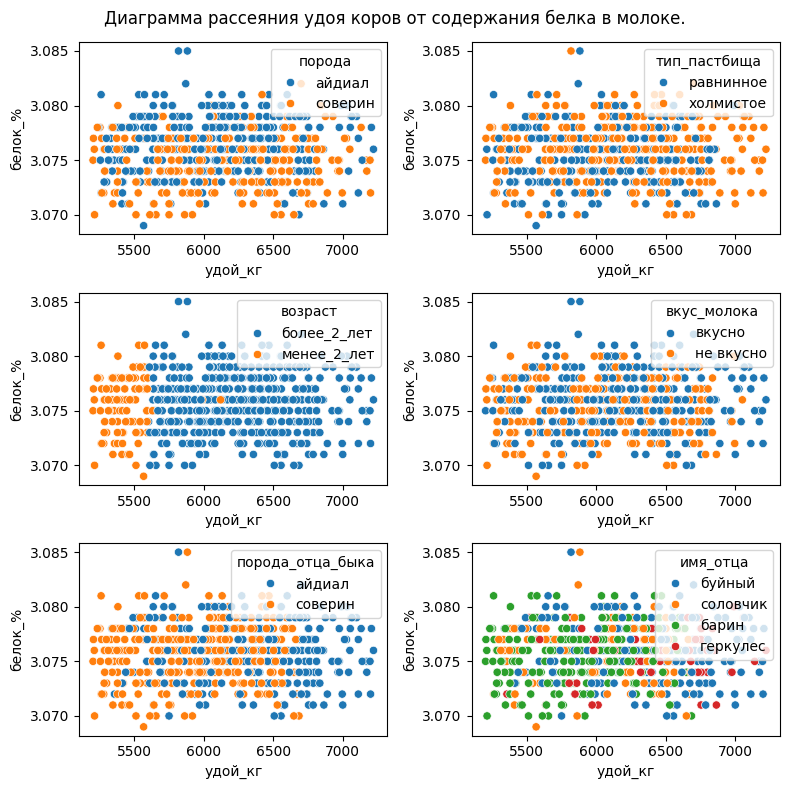

In [66]:
show_scatterplot(
    df = df_ferma,
    x_col = "удой_кг",
    y_col = "белок_%",
    title = 'Диаграмма рассеяния удоя коров от содержания белка в молоке.'
)

Содержание белка не влияет на удой, коэффициент Пирсона - 0, линейной корреляции нет. На графике нелинейной связи не обнаружено, значения распределены равномерно по обеим осям. В дальнейшем уберем этот признак.

### Изучение влияния категориальных признаков

Влияние категориальных признаков при изучении каждого количесвенного было неизменным. Выделяются два, в которых связь значений видна неворуженным глазом - возраст коровы и порода отца, а также один дополнительный признак - тип пастбища.

Остальные признаки вкус молока, порода, имя отца меют равномерное распределение для всего диапазона удоя коров.

**Гипотеза №1: Годовой удой коров моложе 2 лет не превышает 5600 кг, есть несколько выбросов.**

In [67]:
hyp_1 = df_ferma.query('удой_кг > 5600').pivot_table(
    values = 'удой_кг',
    index = 'возраст',
    aggfunc = 'count'
)

for name, values in df_ferma['возраст'].value_counts().items():
    hyp_1.loc[hyp_1.index == name,'процент'] = (hyp_1.loc[hyp_1.index == name,'удой_кг'] / values).round(2)*100

hyp_1.columns =  ['кол-во', 'процент значений внутри группы']
hyp_1

,кол-во,процент значений внутри группы
возраст,,
более_2_лет,518,100.0
менее_2_лет,5,5.0


В сводной таблице показано, что только 5 процентов коров моложе 2 лет имеют годовой удой более 5600кг, причем все коровы старше 2 лет порог прошли.

**Гипотеза №2: В среднем удой коров породы айдиал выше, чем соверин.**

In [68]:
for i in df_ferma['порода_отца_быка'].unique():
    print(f"Средний удой для породы {i} составляет: {df_ferma[df_ferma['порода_отца_быка'] == i]['удой_кг'].mean()}")

Средний удой для породы айдиал составляет: 6363.669064748202
Средний удой для породы соверин составляет: 5937.165714285714


Построим диаграммы размаха для удоя коров от разных отцов.

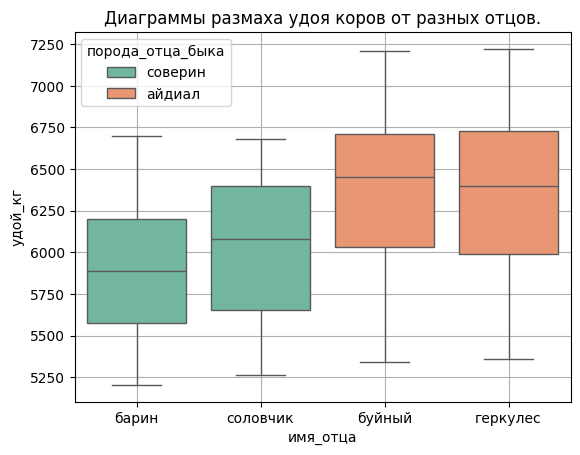

In [69]:
sns.boxplot(
    y = 'удой_кг',
    x = 'имя_отца',
    data = df_ferma.sort_values(by='порода_отца_быка', ascending = False), # чтобы цвет породы соответствовал предыдущим графикам
    hue = 'порода_отца_быка',
    palette = colors
)
plt.title('Диаграммы размаха удоя коров от разных отцов.')
plt.grid(True)
plt.show()

Из этого следует, что удой у коров, чьи отцы Геркулес и Буйный (айдиал)- в среднем выше, чем Барин и Соловчик (соверин). Причем значения внутри породы айдиал распределены равномерно, а в породе соверин - Совочик имеет выше среднее, чем Барин. Из этого следует, что признаки имя отца и порода отца быка - коллинеарны, причем из двух характеристик первый лучше объясняет разницу удоя.

**Гипотеза №3: В среднем удой коров, выращенных на холмистых пастибах выше, чем на равнинных.**

In [70]:
for i in df_ferma['тип_пастбища'].unique():
    print(f"Средний удой для у коров, выращенных на пастбище с типом {i}, составляет: {df_ferma[df_ferma['тип_пастбища'] == i]['удой_кг'].mean()}")

Средний удой для у коров, выращенных на пастбище с типом равнинное, составляет: 6056.287769784172
Средний удой для у коров, выращенных на пастбище с типом холмистое, составляет: 6181.314285714286


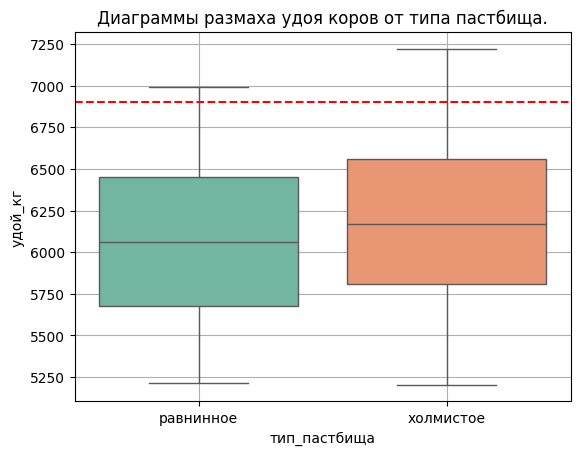

In [71]:
sns.boxplot(
    y = 'удой_кг',
    x = 'тип_пастбища',
    data = df_ferma, 
    hue = 'тип_пастбища',
    legend = False,
    palette = colors
)
plt.axhline(y=6900, color='r', linestyle='--')
plt.title('Диаграммы размаха удоя коров от типа пастбища.')
plt.grid(True)
plt.show()

In [72]:
df_ferma.query('удой_кг > 6900').pivot_table(
    values = 'удой_кг',
    index = 'тип_пастбища',
    aggfunc = 'count'
)

,удой_кг
тип_пастбища,
равнинное,1
холмистое,28


Действительно, средний удой у коров, выращенных на холмистых пастбищ, выше. Причем распределение показало, что разброс значений у последних больше, что позволяет встретить 28 таких коров в зоне более 6900 кг удоя. 

**Гипотеза №4: Порода коровы не влияет на ее удой.**

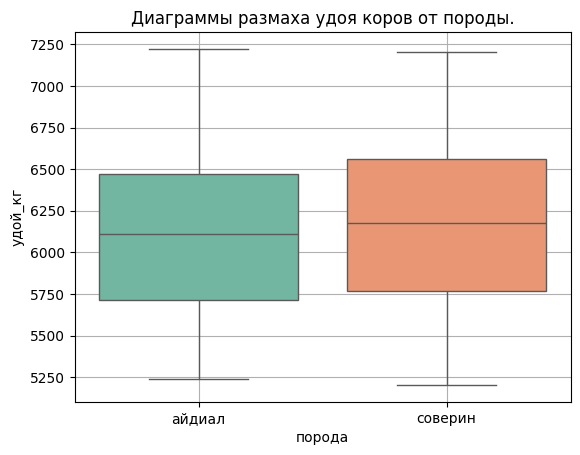

In [73]:
sns.boxplot(
    y = 'удой_кг',
    x = 'порода',
    data = df_ferma, 
    hue = 'порода',
    legend = False,
    palette = colors
)

plt.title('Диаграммы размаха удоя коров от породы.')
plt.grid(True)
plt.show()

Диаграммы размаха лежат в одном промежутке значений. Да, порода не влияет на удой коровы.

### Вывод

1) Тип связи между между целевым (удой_кг) и входными признаками:
 - ЭКЕ корма - нелинейная положительная
 - СПО корма - нелинейная положительная
 - Жирность молока - нелинейная положительная
 - Сырой протеин в корме - линейная положительная
 - Белок в молоке - нет связи
 - Вкус молока - нет связи
 - Порода коровы - визуально зависимости нет
 - Тип пастбища - есть связь
 - Возраст - есть связь
 - Имя отца быка - есть связь
 - Порода отца быка - есть связь

2) Нелинейные взаимосвязи и новые признаки:
 - ЭКЕ - возвеведение значений в квадрат (новый признак - `эке_2`) 
 - СПО - преобразование в категориальный признак с порогом в 0.925 у.е. (новый признак - `спо_кат`)
 - жирность - по причинно-следственной связи признак редактировать не требуется при изучении удоя

4) Выявлена мультиколлинеарность признаков:
 - ЭКЕ (связана с признаком СПО, коэффициент корреляции Пирсона в паре - 0.75)
 - Порода отца быка (дублирует информацию в признаке имя отца)

## Обучение модели линейной регрессии

### Модель №1

In [74]:
df_ferma.head()

,id,удой_кг,эке,сырой_протеин_г,спо,порода,тип_пастбища,порода_отца_быка,жирность_%,белок_%,вкус_молока,возраст,имя_отца,эке_2,спо_кат
0,1,5863,14.2,1743,0.890,айдиал,равнинное,айдиал,3.58,3.076,вкусно,более_2_лет,буйный,201.64,0
1,2,5529,12.8,2138,0.890,айдиал,равнинное,соверин,3.54,3.079,вкусно,менее_2_лет,соловчик,163.84,0
2,3,5810,14.0,1854,0.885,соверин,холмистое,соверин,3.59,3.074,не вкусно,более_2_лет,барин,196.00,0
3,4,5895,12.4,2012,0.885,соверин,холмистое,айдиал,3.40,3.075,не вкусно,более_2_лет,буйный,153.76,0
4,5,5302,12.8,1675,0.885,айдиал,равнинное,соверин,3.73,3.073,вкусно,менее_2_лет,барин,163.84,0


Приступим к подготовке данных для построения модели линейной регрессии. Создадим новый датафрейм с необходимыми признаками. 

Целевой признак - `удой_кг`
  
По характеристикам молока можно предсказать только его вкус и качество, но удой - кол-во продукта - нет. Однако, мы определили, что связь между удоем и жирностью молока присутствует (коэф Пирсона - 0.6), видимо, жирность зависит от удоя, а не наоборот. Поэтому признаки `жирность, белок и вкус молока` не попадут в тренировочную выборку модели регрессии.

Для регрессионной модели №1 возьмем следующие входные признаки:

 - ЭКЕ корма (до изменения)
 - СПО корма (до изменения)
 - сырой протеин
 - тип пастбища
 - порода отца
 - возраст
 - порода коровы

Создадим функцию для маштабирования и кодирования признаков.

In [75]:
def scale_data(cat_col_names, num_col_names, X_train, X_test):
    
    # закодируем категориальные признаки методом OHE
    # sparse_output=False, чтобы отобразить данные далее, drop = 'first' - избавляемся от мультиколлинеарности
    encoder = OneHotEncoder(sparse_output=False, drop = 'first') 
    X_train_ohe = encoder.fit_transform(X_train[cat_col_names]) 
    X_test_ohe = encoder.transform(X_test[cat_col_names])
    encoder_col_names = encoder.get_feature_names_out() # получим название новых столбцов

    # сформируем новые датафреймы с закодированными признаками
    X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)
    X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names)

    # проведем стандартизацию количественных признаков
    scaler = StandardScaler() 
    X_train_scaled = scaler.fit_transform(X_train[num_col_names])
    X_test_scaled = scaler.transform(X_test[num_col_names])

    # сформируем новые датафреймы с стандартизованными признаками
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names)

    # получим конечные выборки, объединив данные из подготовленными признаками
    X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)
    X_test = pd.concat([X_test_ohe, X_test_scaled], axis=1)
    
    return X_train, X_test

Теперь функцию обучения модели линейной регрессии.

In [76]:
def create_lr_model(
    data,
    tagret_col,
    cat_col_names,
    num_col_names,
    model_name = 'lr_n'
):

    # подготовим выборки
    X = data.drop(tagret_col, axis = 1)
    y = data[tagret_col]
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=RANDOM_STATE)
    
    # маштабирование и кодирование признаков
    X_train, X_test = scale_data(cat_col_names, num_col_names, X_train, X_test)

    # строим модель линейной регрессии
    model_lr = LinearRegression()
    model_lr.fit(X_train, y_train)
    predictions = model_lr.predict(X_test) # получаем предсказания модели

    residuals = y_test - predictions # для дальнейших тестов получим остатки работы модели

    # построим графики по количественным признакам — гистограмму частотности распределения и диаграмму рассеяния
    _, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,5))
    sns.histplot(residuals, ax = ax[0])
    ax[0].set_title('Гистограмма распределения остатков')
    ax[0].set_xlabel('Остатки')

    sns.scatterplot(x = predictions, y = residuals, ax = ax[1])
    ax[1].set_xlabel('Предсказания модели')
    ax[1].set_ylabel('Остатки')
    ax[1].set_title('Анализ дисперсии')
    plt.show()
    
    # Получим метрики для сравнения моделей
    r2 = r2_score(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = root_mean_squared_error(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    
    # Используем 0.95 доверительный интервал
    lower_quantile = np.quantile(residuals, 0.025)
    upper_quantile = np.quantile(residuals, 0.975) 
    
    # Запишем все метрики датафрейм
    return pd.DataFrame(
        {
            'name': [model_name],
            'R^2': [r2],
            'MSE': [mse],
            'RMSE': [rmse],
            'MAE': [mae],
            '0.025_quantile': [lower_quantile],
            '0.975_quantile': [upper_quantile],
        })
    

In [77]:
df_lr_1 = df_ferma[['удой_кг', 'эке','сырой_протеин_г', 'спо', 'тип_пастбища', 'возраст', 'порода_отца_быка', 'порода']]
df_lr_1.head()

,удой_кг,эке,сырой_протеин_г,спо,тип_пастбища,возраст,порода_отца_быка,порода
0,5863,14.2,1743,0.890,равнинное,более_2_лет,айдиал,айдиал
1,5529,12.8,2138,0.890,равнинное,менее_2_лет,соверин,айдиал
2,5810,14.0,1854,0.885,холмистое,более_2_лет,соверин,соверин
3,5895,12.4,2012,0.885,холмистое,более_2_лет,айдиал,соверин
4,5302,12.8,1675,0.885,равнинное,менее_2_лет,соверин,айдиал


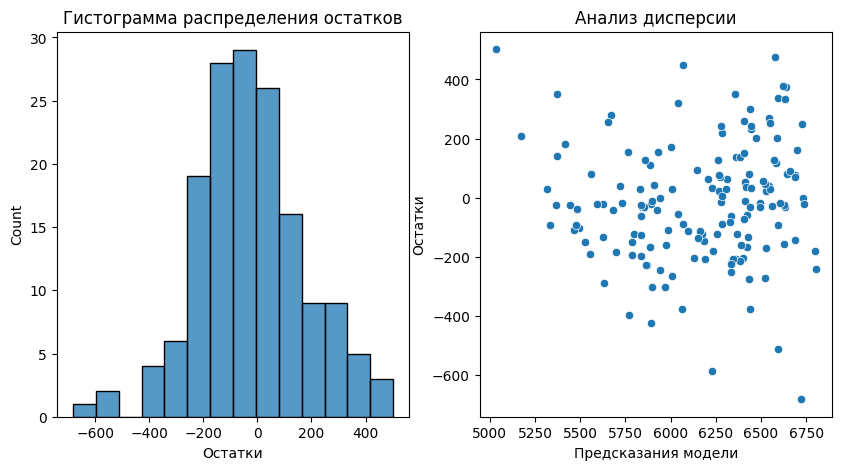

,name,R^2,MSE,RMSE,MAE,0.025_quantile,0.975_quantile
0,lr_1,0.802221,40260.841333,200.651044,155.210636,-400.902879,374.516239


In [78]:
lr_1 = create_lr_model(
    data = df_lr_1,
    tagret_col = 'удой_кг',
    cat_col_names = ['тип_пастбища','возраст', 'порода_отца_быка', 'порода'],
    num_col_names = ['эке','сырой_протеин_г', 'спо'],
    model_name = 'lr_1'
)
lr_1

**Вывод:**
- Коэффициент детерминации показывает, что модель лучше предсказывает удой, чем среднее (тк $R^2$ близок к 1)
- Анализ остатков выявил наличие выброса при ошибке менее -600. Исключая выбросы дисперсия будет постоянной на оси Y.
- При сравнении моделей приоритет будем отдаватьь метрике MAE, тк она более робастна 
- Изучим следующие комбинации признаков

### Модель №2

Для регрессионной модели №2 возьмем следующие входные признаки:

 - ЭКЕ корма (после изменения)
 - СПО корма (после изменения)
 - сырой протеин
 - тип пастбища
 - порода отца
 - возраст
 - порода коровы

In [79]:
df_lr_2 = df_ferma[['удой_кг', 'эке_2','сырой_протеин_г', 'спо_кат', 'тип_пастбища', 'возраст', 'порода_отца_быка', 'порода']]
df_lr_2.head()

,удой_кг,эке_2,сырой_протеин_г,спо_кат,тип_пастбища,возраст,порода_отца_быка,порода
0,5863,201.64,1743,0,равнинное,более_2_лет,айдиал,айдиал
1,5529,163.84,2138,0,равнинное,менее_2_лет,соверин,айдиал
2,5810,196.00,1854,0,холмистое,более_2_лет,соверин,соверин
3,5895,153.76,2012,0,холмистое,более_2_лет,айдиал,соверин
4,5302,163.84,1675,0,равнинное,менее_2_лет,соверин,айдиал


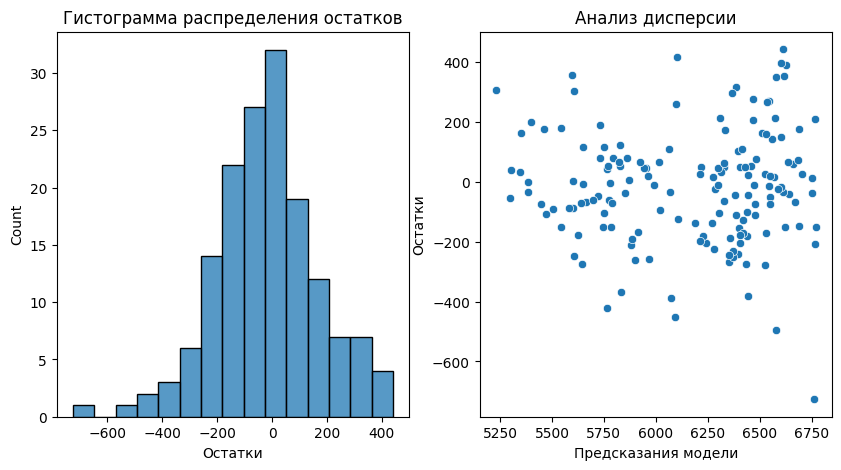

,name,R^2,MSE,RMSE,MAE,0.025_quantile,0.975_quantile
0,lr_2,0.823795,35869.165413,189.391566,144.911512,-390.396438,358.052265


In [80]:
lr_2 = create_lr_model(
    data = df_lr_2,
    tagret_col = 'удой_кг',
    cat_col_names = ['спо_кат', 'тип_пастбища', 'возраст', 'порода_отца_быка'],
    num_col_names = ['эке_2','сырой_протеин_г'],
    model_name = 'lr_2'
)
lr_2

**Вывод:**
- Использование обработанных признаков (эке и спо), положительно влияет на качество модели. 
- Распределние выглядит более `нормально`, с модой в нуле.
- Метрика MAE снизилась, относительно первой модели.
- Изучим следующие комбинации признаков

### Модель №3

Для регрессионной модели №3 возьмем следующие входные признаки:

 - ЭКЕ корма (после изменения)
 - СПО корма (после изменения)
 - сырой протеин
 - тип пастбища
 - порода отца
 - возраст
 - порода коровы
 - имя отца

In [81]:
df_lr_3 = df_ferma[['удой_кг', 'эке_2','сырой_протеин_г', 'спо_кат', 'тип_пастбища', 'возраст', 'порода_отца_быка', 'имя_отца', 'порода']]
df_lr_3.head()

,удой_кг,эке_2,сырой_протеин_г,спо_кат,тип_пастбища,возраст,порода_отца_быка,имя_отца,порода
0,5863,201.64,1743,0,равнинное,более_2_лет,айдиал,буйный,айдиал
1,5529,163.84,2138,0,равнинное,менее_2_лет,соверин,соловчик,айдиал
2,5810,196.00,1854,0,холмистое,более_2_лет,соверин,барин,соверин
3,5895,153.76,2012,0,холмистое,более_2_лет,айдиал,буйный,соверин
4,5302,163.84,1675,0,равнинное,менее_2_лет,соверин,барин,айдиал


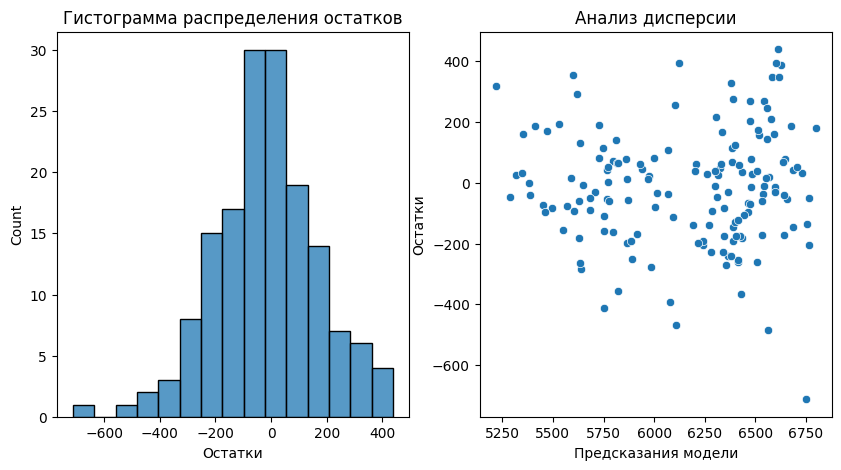

,name,R^2,MSE,RMSE,MAE,0.025_quantile,0.975_quantile
0,lr_3,0.826512,35316.00436,187.925529,144.638137,-393.154486,357.600036


In [82]:
lr_3 = create_lr_model(
    data = df_lr_3,
    tagret_col = 'удой_кг',
    cat_col_names = ['спо_кат', 'тип_пастбища', 'возраст', 'порода_отца_быка', 'имя_отца', 'порода'],
    num_col_names = ['сырой_протеин_г', 'эке_2'],
    model_name = 'lr_3'
)
lr_3

**Гипотеза №5: увеличится ли коэффициент детерминации, если заменить признак `порода отца` на `имя отца`.**

In [83]:
df_lr_3_test = df_ferma[['удой_кг', 'эке_2','сырой_протеин_г', 'спо_кат', 'тип_пастбища', 'возраст', 'имя_отца', 'порода']]
df_lr_3_test.head()

,удой_кг,эке_2,сырой_протеин_г,спо_кат,тип_пастбища,возраст,имя_отца,порода
0,5863,201.64,1743,0,равнинное,более_2_лет,буйный,айдиал
1,5529,163.84,2138,0,равнинное,менее_2_лет,соловчик,айдиал
2,5810,196.00,1854,0,холмистое,более_2_лет,барин,соверин
3,5895,153.76,2012,0,холмистое,более_2_лет,буйный,соверин
4,5302,163.84,1675,0,равнинное,менее_2_лет,барин,айдиал


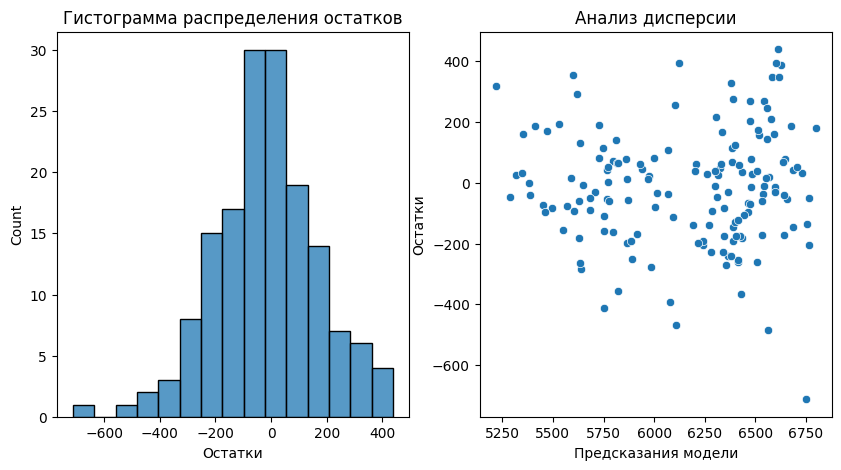

,name,R^2,MSE,RMSE,MAE,0.025_quantile,0.975_quantile
0,lr_3_t,0.826512,35316.00436,187.925529,144.638137,-393.154486,357.600036


In [84]:
lr_3_t = create_lr_model(
    data = df_lr_3_test,
    tagret_col = 'удой_кг',
    cat_col_names = ['спо_кат', 'тип_пастбища', 'возраст', 'имя_отца', 'порода'],
    num_col_names = ['эке_2','сырой_протеин_г'],
    model_name = 'lr_3_t'
)
lr_3_t

Нет, коэффициент детерминации $R^2$ не стал больше. Однако, удаление признака не повлияло на качество модели, все метрики идентичные. 
Из этого следует, что признак `порода_отца_быка` коррелирует с признаком `имя отца`, в данной модели избавились от мультиколлинеарности.

**Вывод:**
- Была обработана мультиколлинеарность, путем удаления признака `порода_отца_быка`.
- При добавлении характеристики `имя_отца` качество увеличилось ($R^2$ - больше, MAE - меньше) относительно модели №2

### Выбор модели и подготовка данных

Сравним метртики моделей в одной таблице.

In [85]:
pd.concat([lr_1, lr_2, lr_3, lr_3_t]).reset_index(drop=True)

,name,R^2,MSE,RMSE,MAE,0.025_quantile,0.975_quantile
0,lr_1,0.802221,40260.841333,200.651044,155.210636,-400.902879,374.516239
1,lr_2,0.823795,35869.165413,189.391566,144.911512,-390.396438,358.052265
2,lr_3,0.826512,35316.004360,187.925529,144.638137,-393.154486,357.600036
3,lr_3_t,0.826512,35316.004360,187.925529,144.638137,-393.154486,357.600036


Наилучшая модель - `lr_3_t`, в ней наименьший показатель `MAE`, наибольший $R^2$, обработана мультиколлинеарность. При доверительном интервале `0.95` значения ошибки распределены примерно равномерно относительно нуля. 

---

Подготовим датасет тестовой выборки `df_3` для последующего использования в моделе.

In [86]:
df_3.head()

,порода,тип_пастбища,порода_отца_быка,имя_отца,жирность_%,белок_%,возраст
0,айдиал,холмистое,айдиал,геркулес,3.58,3.076,более_2_лет
1,айдиал,равнинное,айдиал,буйный,3.54,3.081,менее_2_лет
2,соверин,равнинное,соверин,барин,3.59,3.074,более_2_лет
3,соверин,холмистое,айдиал,буйный,3.40,3.061,более_2_лет
4,соверин,равнинное,айдиал,буйный,3.64,3.074,более_2_лет


Добавим столбцы и обработаем по тому же принципу, как в выбранной модели.

In [87]:
df_3['эке_2'] = np.power(df_ferma['эке'].mean()*1.05, 2)
df_3['сырой_протеин_г'] = df_ferma['сырой_протеин_г'].mean()*1.05

if df_ferma['спо'].mean()*1.05 > 0.925:
    df_3['спо_кат'] = 1
else: 
    df_3['спо_кат'] = 0
    
#df_3.drop(['жирность_%', 'белок_%'], axis = 1, inplace = True)
df_3['спо'] = df_ferma['спо'].mean()*1.05

df_3.head()

,порода,тип_пастбища,порода_отца_быка,имя_отца,жирность_%,белок_%,возраст,эке_2,сырой_протеин_г,спо_кат,спо
0,айдиал,холмистое,айдиал,геркулес,3.58,3.076,более_2_лет,233.361138,2019.947532,1,0.958744
1,айдиал,равнинное,айдиал,буйный,3.54,3.081,менее_2_лет,233.361138,2019.947532,1,0.958744
2,соверин,равнинное,соверин,барин,3.59,3.074,более_2_лет,233.361138,2019.947532,1,0.958744
3,соверин,холмистое,айдиал,буйный,3.40,3.061,более_2_лет,233.361138,2019.947532,1,0.958744
4,соверин,равнинное,айдиал,буйный,3.64,3.074,более_2_лет,233.361138,2019.947532,1,0.958744


Порядок столбцов не имеет значения, тк далее будут проводиться маштабирование и кодирование признаков. Они делаются параллельно для тренировочной и тестовой выборок по одной последовательности столбцов, заданной в переменной `cat_col_names` или `num_col_names`.

### Получение предсказаний удоя

Мы получили комбинацию признаков, дающих наилучшие предсказания на основе метрик. Переобучим модель на всех имеющихся данных `df_lr_3_t`. В качестве тестовой выборки возьмем `df_3`, где необходимо предсказать удой для коров, рассматриваемых к покупке.

In [88]:
cat_col_names = ['тип_пастбища', 'возраст', 'имя_отца', 'порода', 'спо_кат']
num_col_names = ['сырой_протеин_г', 'эке_2']

# подготовим выборки
X_train = df_lr_3_test.drop('удой_кг', axis = 1)
y_train = df_lr_3_test['удой_кг']
X_test = df_3

# маштабирование и кодирование признаков
X_train, X_test = scale_data(cat_col_names, num_col_names, X_train, X_test)


# строим модель линейной регрессии
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
predictions = model_lr.predict(X_test) # получаем предсказания модели

# подставим предсказания в датафрейм
df_3['удой_кг'] = predictions
df_3

,порода,тип_пастбища,порода_отца_быка,имя_отца,жирность_%,белок_%,возраст,эке_2,сырой_протеин_г,спо_кат,спо,удой_кг
0,айдиал,холмистое,айдиал,геркулес,3.58,3.076,более_2_лет,233.361138,2019.947532,1,0.958744,6583.132896
1,айдиал,равнинное,айдиал,буйный,3.54,3.081,менее_2_лет,233.361138,2019.947532,1,0.958744,6294.258622
2,соверин,равнинное,соверин,барин,3.59,3.074,более_2_лет,233.361138,2019.947532,1,0.958744,6299.220916
3,соверин,холмистое,айдиал,буйный,3.40,3.061,более_2_лет,233.361138,2019.947532,1,0.958744,6593.102834
4,соверин,равнинное,айдиал,буйный,3.64,3.074,более_2_лет,233.361138,2019.947532,1,0.958744,6545.497447
5,соверин,равнинное,айдиал,геркулес,3.63,3.053,менее_2_лет,233.361138,2019.947532,1,0.958744,6350.988412
6,айдиал,равнинное,айдиал,буйный,3.57,3.079,более_2_лет,233.361138,2019.947532,1,0.958744,6512.147584
7,соверин,холмистое,айдиал,буйный,3.40,3.079,менее_2_лет,233.361138,2019.947532,1,0.958744,6375.213872
8,айдиал,холмистое,соверин,соловчик,3.73,3.055,более_2_лет,233.361138,2019.947532,1,0.958744,6349.370877
9,соверин,равнинное,айдиал,геркулес,3.73,3.073,более_2_лет,233.361138,2019.947532,1,0.958744,6568.877373


<div class="alert alert-info"style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px "  
<b> Можно ли так было делать или нужно использовать ту модель, для которой известны метрики? Ведь из-за отсутствия y_test невозможно определить качество.

Получены предсказания, все рассматриваемые к покупке коровы должны иметь удой выше целевого порога в 6000 кг в год.

## Обучение модели логистической регрессии

### Выбор признаков для модели

In [89]:
df_ferma.head()

,id,удой_кг,эке,сырой_протеин_г,спо,порода,тип_пастбища,порода_отца_быка,жирность_%,белок_%,вкус_молока,возраст,имя_отца,эке_2,спо_кат
0,1,5863,14.2,1743,0.890,айдиал,равнинное,айдиал,3.58,3.076,вкусно,более_2_лет,буйный,201.64,0
1,2,5529,12.8,2138,0.890,айдиал,равнинное,соверин,3.54,3.079,вкусно,менее_2_лет,соловчик,163.84,0
2,3,5810,14.0,1854,0.885,соверин,холмистое,соверин,3.59,3.074,не вкусно,более_2_лет,барин,196.00,0
3,4,5895,12.4,2012,0.885,соверин,холмистое,айдиал,3.40,3.075,не вкусно,более_2_лет,буйный,153.76,0
4,5,5302,12.8,1675,0.885,айдиал,равнинное,соверин,3.73,3.073,вкусно,менее_2_лет,барин,163.84,0


Пусть `вкусное` молоко - 1, `невкусное` - 0.

In [90]:
df_ferma['вкус_молока'] = np.where(df_ferma['вкус_молока'] == 'вкусно', 1, 0)

С помощью библиотеки `Phik` выведем коэффициенты корреляции `фk` между целевой признаком - `вкус_молока` и всеми остальными. Отсортируем их по мере уменьшения корреляции.

In [91]:
df_ferma.drop('id', axis = 1).phik_matrix()['вкус_молока'].sort_values(ascending = False)

interval columns not set, guessing: ['удой_кг', 'эке', 'сырой_протеин_г', 'спо', 'жирность_%', 'белок_%', 'вкус_молока', 'эке_2', 'спо_кат']


вкус_молока         1.000000
спо                 0.572702
эке_2               0.305768
эке                 0.272265
тип_пастбища        0.269063
жирность_%          0.198793
сырой_протеин_г     0.176480
удой_кг             0.173122
возраст             0.165974
белок_%             0.143857
спо_кат             0.100949
порода              0.000000
порода_отца_быка    0.000000
имя_отца            0.000000
Name: вкус_молока, dtype: float64

- `Порода, порода_отца_быка, имя_отца` - не имеют связи с целевым признаком. 
- `Эке в квадрате (эке_2)` лучше коррелирует со вкусом молака, чем `эке`.
- `Спо` значительно влияет на целевой признак, но категориальная версия `спо_кат` - имеет минимамльную связь.

Изучим взимосвязь оставшихся признаков на мультиколлинеарность тем же методом.

interval columns not set, guessing: ['вкус_молока', 'эке_2', 'сырой_протеин_г', 'удой_кг', 'жирность_%', 'спо', 'белок_%']


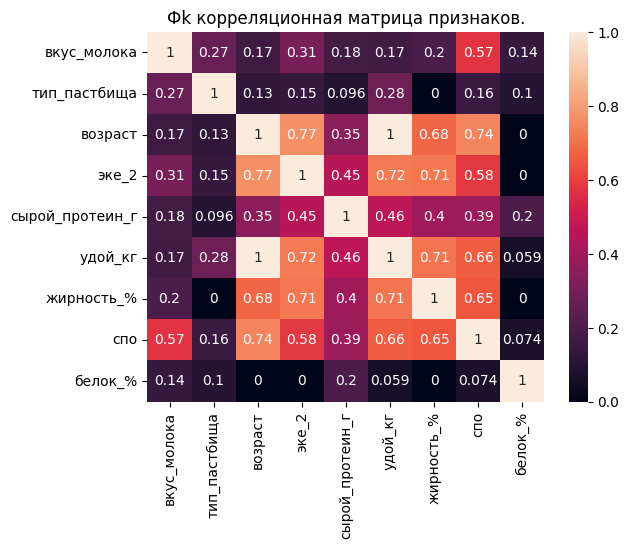

In [92]:
phik = df_ferma[['вкус_молока', 'тип_пастбища','возраст','эке_2','сырой_протеин_г','удой_кг','жирность_%','спо','белок_%']].phik_matrix()
sns.heatmap(phik, annot=True)
plt.title('Фk корреляционная матрица признаков.')
plt.show()

- Возраст и удой дублируют друг друга.

Пока возраст удалять не будем из выборки, изучим, как будет меняться предсказания моделей при разных комбинациях признаков.

In [93]:
df_ferma.drop(['id', 'спо_кат', 'эке'], axis = 1).head()

,удой_кг,сырой_протеин_г,спо,порода,тип_пастбища,порода_отца_быка,жирность_%,белок_%,вкус_молока,возраст,имя_отца,эке_2
0,5863,1743,0.890,айдиал,равнинное,айдиал,3.58,3.076,1,более_2_лет,буйный,201.64
1,5529,2138,0.890,айдиал,равнинное,соверин,3.54,3.079,1,менее_2_лет,соловчик,163.84
2,5810,1854,0.885,соверин,холмистое,соверин,3.59,3.074,0,более_2_лет,барин,196.00
3,5895,2012,0.885,соверин,холмистое,айдиал,3.40,3.075,0,более_2_лет,буйный,153.76
4,5302,1675,0.885,айдиал,равнинное,соверин,3.73,3.073,1,менее_2_лет,барин,163.84


### Создание и выбор классификатора

Далее приступим к подготовке, те маштабированию количественных признаков и кодированию категориальных. Для этого у нас уже создана функция `scale_data`.

Также создадим функцию `show_metrics_def` - которая покажет `матрицу ошибок` и метрики `accuracy, precision и recall`.

Все выше описанные функции объединим в одну `def process_clf_model` - функция создания модели классификации. С помощью условных конструкций можно будет получить разный ответ функции:
- `add_column == True`: будут созданы колонки в 2 таблицы:
    - таблица сравнения весов признаков, которая подскажет, какие признаки имеют больший/меньший вклад, также подсчитает accuracy
    - таблица сравнения предсказаний, в которой выведены 10 строк с макимальной вероятностью
- `show_metrics == True`: функция сразу применит `show_metrics_def` для визуализации метрик
- `return_results == True`: вернет переменные `y_test, predictions, y_proba` для дальнейшего использования

При условии, что фермеру необходимы только коровы со вкусным молоком, будем смотреть на `precision`. Наша задача минимизировать `ошибку первого рода FP`, чтобы модель не предасказала `1` в целевом признаке для коров с невкусным молоком. 


Функция `precision_for_intervals` покажет как меняется значение `precision` в заданном диапазоне. Это функия нужна для определения минимального порога классификации, при которой исчезает ошибка FP.

In [94]:
df_weights = pd.DataFrame() # таблица сравнения весов признаков
df_proba = pd.DataFrame() # таблица сравнения вероятностей предсказаний

def show_metrics_def(y_test, predictions):
    print('accuracy: ',round(accuracy_score(y_test, predictions),3)) # вывод точностии предсказания accuracy
    print('recall: ',round(recall_score(y_test, predictions) ,3)) # метрика recall - анализ ошибки 2-го рода FN
    print('precision: ',round(precision_score(y_test, predictions)  ,3)) # метрика precision - анализ ошибки 1-го рода FP
    sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='d', cmap='Blues_r')        
    plt.title('Confusion matrix')
    plt.ylabel('True label')
    plt.xlabel('Predicted') 
    plt.show()

def process_clf_model(
    cat_col_names,
    num_col_names,
    model_n = 'model_n',
    add_column = False,
    show_metrics = False,
    return_results = False
):
    
    # подготовим выборки
    X = df_ferma.drop('вкус_молока', axis = 1)
    y = df_ferma['вкус_молока']
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=RANDOM_STATE) 
    
    # маштабирование и кодирование признаков
    X_train, X_test = scale_data(cat_col_names, num_col_names, X_train, X_test)
    
    # обучение модели логистической регрессии
    clf = LogisticRegression()
    clf.fit(X_train, y_train)
    predictions = clf.predict(X_test) # получаем предсказания модели
    y_proba = clf.predict_proba(X_test)[:,1] # получаем веротности предсказаний
 
    if add_column == True:
        
        # строим таблицу, показывающую экспонецированные веса признаков (для наглядности интерпритации) 
        for feature_number, feature_name in enumerate(X[cat_col_names + num_col_names].columns):
            exp_weight = math.exp(clf.coef_[0, feature_number]) # возводим `е` в степень logit (wi)
            df_weights.loc[feature_name, model_n] = exp_weight
        df_weights.loc['accuracy', model_n] = accuracy_score(y_test, predictions) # добавляем accuracy
        
        # строим таблицу сравнения вероятности предсказаний
        df_proba_add = (
            pd.DataFrame(
                zip(y_test, y_proba), # склеиваем предсказания и их вероятности
                columns = pd.MultiIndex.from_arrays([[model_n, model_n],['y_valid', 'y_proba']]) # делаем двухярсные названия колонок
            )
        .sort_values(by=[(model_n,'y_proba')],ascending=False)
        .head(10)
        .reset_index(drop = True) # сбрасываем индесы, чтобы не конфликтовало объединение таблиц
        )
        global df_proba # обращаемся к ранее созданной вне функции переменной и редактируем ее
        df_proba = pd.concat([df_proba, df_proba_add], axis=1)
    
    if show_metrics == True:
        show_metrics_def(y_test, predictions)
        
    if return_results == True:
        return y_test, predictions, y_proba

    
def precision_for_intervals(start,stop,num, y_test, y_proba):
    
    thresholds = [round(i,3) for i in np.linspace(start,stop,num,endpoint=False)]
    print(thresholds)
    results = []
    for threshold in thresholds: 
        y_pred = (y_proba > threshold).astype(int) # преобразуем вероятности в метки
        results.append({
            "Порог": f"y_pred_{threshold}",
            "precision": precision_score(y_test, y_pred), # вычисляем precision
            "FP": confusion_matrix(y_test, y_pred)[0, 1],  # FP находится в [0, 1] ячейке confusion_matrix
            "Число предсказанных объектов": sum(y_pred), # число предсказанных объектов класса 1
            "Всего объектов класса 1": sum(y_test) # общее число объектов класса 1
        }) 
    display(pd.DataFrame(results)) # создание таблицы

In [95]:
# модель 1 - изучим веса всех признаков, посмотрим на предсказания
process_clf_model(
    cat_col_names = ['тип_пастбища','возраст'],
    num_col_names = ['эке_2','сырой_протеин_г','удой_кг','жирность_%','спо','белок_%'],
    model_n = 'model_1',
    add_column = True,
    show_metrics = False,
    return_results = False
)
# модель 2 - уберем признак `возраст`, ввиду мультиколлинеарности с признаком `удой`
process_clf_model(
    cat_col_names = ['тип_пастбища'],
    num_col_names = ['эке_2','сырой_протеин_г','удой_кг','жирность_%','спо','белок_%'],
    model_n = 'model_2',
    add_column = True,
    show_metrics = False,
    return_results = False
)
# модель 3 - теперь, наоборот, уберем `удой`, а по `возраст` оставим
process_clf_model(
    cat_col_names = ['тип_пастбища','возраст'],
    num_col_names = ['эке_2','сырой_протеин_г','жирность_%','спо','белок_%'],
    model_n = 'model_3',
    add_column = True,
    show_metrics = False,
    return_results = False
)
# модель 4 - уберем признак `сырой протеин`, тк его вес в модели 3 равен 1.07, что близко к 1, а значит имеет минимальный вес
process_clf_model(
    cat_col_names = ['тип_пастбища','возраст'],
    num_col_names = ['эке_2','жирность_%','спо','белок_%'],
    model_n = 'model_4',
    add_column = True,
    show_metrics = False,
    return_results = False
)

# модель 5 - уберем `возраст` и `сырой протиеин`
process_clf_model(
    cat_col_names = ['тип_пастбища'],
    num_col_names = ['эке_2','удой_кг','жирность_%','спо','белок_%'],
    model_n = 'model_5',
    add_column = True,
    show_metrics = False,
    return_results = False
)
# модель 6 - уберем `возраст`, `сырой протиеин` и `жирность` (тк корреляция с удоем - 0.71)
process_clf_model(
    cat_col_names = ['тип_пастбища'],
    num_col_names = ['эке_2','удой_кг','спо','белок_%'],
    model_n = 'model_6',
    add_column = True,
    show_metrics = False,
    return_results = False
)

In [96]:
display(df_weights)
df_proba

,model_1,model_2,model_3,model_4,model_5,model_6
тип_пастбища,1.824285,1.816330,1.702837,1.708930,1.820455,1.843712
возраст,0.687134,NaN,0.944848,0.941581,NaN,NaN
эке_2,1.652337,1.673054,1.431549,1.438284,1.672795,1.626649
сырой_протеин_г,1.121780,1.115657,1.074728,NaN,NaN,NaN
удой_кг,0.588453,0.641139,NaN,NaN,0.656609,0.648331
жирность_%,0.888062,0.907136,0.875965,0.882408,0.915234,NaN
спо,1.484358,1.471796,1.186350,1.210213,1.500971,1.459445
белок_%,1.237056,1.239628,1.266603,1.285620,1.268716,1.272805
accuracy,0.662420,0.630573,0.617834,0.617834,0.656051,0.643312


model_1           model_2           model_3           model_4            \
  y_valid   y_proba y_valid   y_proba y_valid   y_proba y_valid   y_proba   
0       1  0.842940       1  0.836538       1  0.825801       1  0.826540   
1       1  0.832669       1  0.826121       1  0.824380       1  0.822030   
2       1  0.831857       1  0.822367       0  0.822052       1  0.812584   
3       0  0.829489       1  0.820268       1  0.809682       0  0.808750   
4       1  0.827211       1  0.817910       1  0.805331       1  0.802524   
5       1  0.822592       0  0.812802       1  0.795234       1  0.791744   
6       1  0.819749       1  0.810390       1  0.794252       1  0.791644   
7       1  0.808552       1  0.808117       1  0.786280       0  0.790959   
8       1  0.804728       1  0.802445       1  0.784228       1  0.790534   
9       1  0.800367       1  0.801966       0  0.779898       1  0.778597   

  model_5           model_6            
  y_valid   y_proba y_valid   y_proba  
0       1  0.843193       1  0.845487  
1       1  0.825609       1  0.826745  
2       0  0.812919       0  0.816177  
3       1  0.811520       1  0.814725  
4       0  0.807201       0  0.814236  
5       1  0.799389       1  0.803427  
6       1  0.798251       1  0.798171  
7       1  0.796925       1  0.796456  
8       1  0.793723       1  0.791438  
9       0  0.792404       1  0.789370

In [97]:
#df_weights = df_weights.drop('model_9', axis =1)

Модель 1:
- Имеет два дублирующих признака `удой`, `возраст`
- Эта модель выведенена для сравнения
- Точность предсказания - максимальная среди других моделей

Модель 2:
- Удаление признака `возраст` снизило точность предсказания на 3%
- Однако первые 5 строк в таблице вероятностей оказались правильно предсказанными

Модель 3:
- Удаление признака `удой` снизило точность предсказания на 4.5%
- Признак `удой` более значим, чем `возраст`, что и было показано в матрице корреляции Фk
- Порог классификации тяжело определить, тк третье значение от верху в таблице вероятности отнесено к нулевому классу.
- Признак `сырой протеин` имеет низкую значимость, тк значение блико к 1

Модель 4
- Удаление признака `сырой протеин` не изменило точность предсказания моделью 4, действительно, влияние этого признака - незначительное
- Тяжело подобрать порог классификации

Модель 5
- Комбинируем удаление признаков `возраст` и `сырой протеин`
- Точность значительно выросла до 65.6%
- Тяжело подобрать порог классификации
- Влияние признака `жирность` минимальное

Модель 6
- Удаление признака `жирность` незначительно снизило точность предсказанания
- Тяжело подобрать порог классификации


**Для дальнейшего использования выберем Модель 2, за счет возможности подобрать порог классификации. В других случаях вероятность получить ошибки 2-го рода - максимальны. Это может привести к отсутствию значений при изучении коров фермера.**

### Изменение порога классификации

Применим функцию с возвратом результата модели 2. Визуализируем их.

accuracy:  0.631
recall:  0.852
precision:  0.625


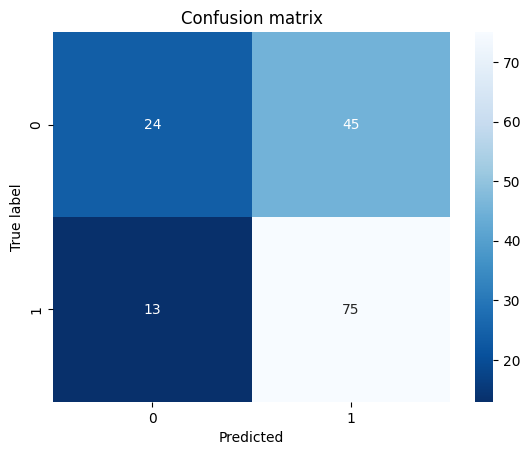

In [98]:
y_test, predictions, y_proba = process_clf_model(
    cat_col_names = ['тип_пастбища'],
    num_col_names = ['эке_2','сырой_протеин_г','удой_кг','жирность_%','спо','белок_%'],
    show_metrics = True,
    return_results = True
)

Напомню: задача - минимизировать `ошибку первого рода FP` или сделать `precision` макимальным.


Обозначим диапазон вероятностей, при котором была выявлена последняя ошибка в модели 2, это 0.81-0.82.

In [99]:
precision_for_intervals(
    start = 0.81,
    stop = 0.82,
    num = 10, # разделим на 10 частей
    y_test = y_test,
    y_proba = y_proba
)

[0.81, 0.811, 0.812, 0.813, 0.814, 0.815, 0.816, 0.817, 0.818, 0.819]


,Порог,precision,FP,Число предсказанных объектов,Всего объектов класса 1
0,y_pred_0.81,0.857143,1,7,88
1,y_pred_0.811,0.833333,1,6,88
2,y_pred_0.812,0.833333,1,6,88
3,y_pred_0.813,1.000000,0,5,88
4,y_pred_0.814,1.000000,0,5,88
5,y_pred_0.815,1.000000,0,5,88
6,y_pred_0.816,1.000000,0,5,88
7,y_pred_0.817,1.000000,0,5,88
8,y_pred_0.818,1.000000,0,4,88
9,y_pred_0.819,1.000000,0,4,88


Порог классификации, при котором `precision = 1` - 0.813. Изменим предсказания для нового порога.

accuracy:  0.471
recall:  0.057
precision:  1.0


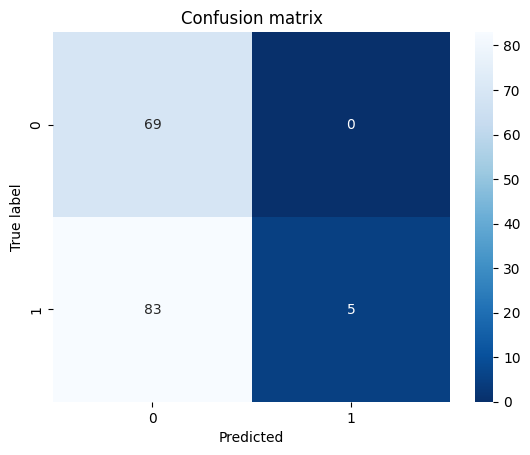

In [100]:
y_pred = (y_proba > 0.813).astype(int)
show_metrics_def(y_test, y_pred)

Критическу `ошибку 1-го рода` мы свели к нулю, `precision` - максимальный. Значение `recall` имеет максимально возможное значение среди всех изученных моделей (1-6). Хотя `accuracy` значительно снизился до 47.1%, зато модель относит к `классу 1` только коров со вкусным молоком. Модель готова, приступим к данным фермера.

### Получение предсказаний вкуса молока

Получим предсказания, используя параметры полученной ранее Модели 2.

In [106]:
# обозначим данные Модели 2 и порог классификации
cat_col_names = ['тип_пастбища']
num_col_names = ['эке_2','сырой_протеин_г','удой_кг','жирность_%','спо','белок_%']
clf_threshold = 0.813
    
# подготовим выборки
X_train = df_ferma.drop('вкус_молока', axis = 1)
y_train = df_ferma['вкус_молока']
X_test = df_3

# маштабирование и кодирование признаков
X_train, X_test = scale_data(cat_col_names, num_col_names, X_train, X_test)

# строим модель логистической регрессии
clf = LogisticRegression()
clf.fit(X_train, y_train)
predictions = (clf.predict_proba(X_test)[:,1] > clf_threshold).astype(int)

# подставим предсказания в датафрейм
df_3['вкус_молока'] = predictions
df_3

,порода,тип_пастбища,порода_отца_быка,имя_отца,жирность_%,белок_%,возраст,эке_2,сырой_протеин_г,спо_кат,спо,удой_кг,вкус_молока
0,айдиал,холмистое,айдиал,геркулес,3.58,3.076,более_2_лет,233.361138,2019.947532,1,0.958744,6583.132896,0
1,айдиал,равнинное,айдиал,буйный,3.54,3.081,менее_2_лет,233.361138,2019.947532,1,0.958744,6294.258622,0
2,соверин,равнинное,соверин,барин,3.59,3.074,более_2_лет,233.361138,2019.947532,1,0.958744,6299.220916,0
3,соверин,холмистое,айдиал,буйный,3.40,3.061,более_2_лет,233.361138,2019.947532,1,0.958744,6593.102834,0
4,соверин,равнинное,айдиал,буйный,3.64,3.074,более_2_лет,233.361138,2019.947532,1,0.958744,6545.497447,0
5,соверин,равнинное,айдиал,геркулес,3.63,3.053,менее_2_лет,233.361138,2019.947532,1,0.958744,6350.988412,0
6,айдиал,равнинное,айдиал,буйный,3.57,3.079,более_2_лет,233.361138,2019.947532,1,0.958744,6512.147584,0
7,соверин,холмистое,айдиал,буйный,3.40,3.079,менее_2_лет,233.361138,2019.947532,1,0.958744,6375.213872,1
8,айдиал,холмистое,соверин,соловчик,3.73,3.055,более_2_лет,233.361138,2019.947532,1,0.958744,6349.370877,0
9,соверин,равнинное,айдиал,геркулес,3.73,3.073,более_2_лет,233.361138,2019.947532,1,0.958744,6568.877373,0


Напомним критерии фермера: корова должна давать `не менее 6000 кг в год вкусного молока`. Отсортируем подходящих коров.

In [107]:
cows_to_buy = df_3.query('вкус_молока == 1 and удой_кг > 6000')
cows_to_buy

,порода,тип_пастбища,порода_отца_быка,имя_отца,жирность_%,белок_%,возраст,эке_2,сырой_протеин_г,спо_кат,спо,удой_кг,вкус_молока
7,соверин,холмистое,айдиал,буйный,3.40,3.079,менее_2_лет,233.361138,2019.947532,1,0.958744,6375.213872,1
11,айдиал,холмистое,соверин,барин,3.42,3.075,менее_2_лет,233.361138,2019.947532,1,0.958744,6095.587478,1
13,айдиал,холмистое,соверин,соловчик,3.73,3.079,более_2_лет,233.361138,2019.947532,1,0.958744,6349.370877,1


## Итоговые выводы

Модели линейной и логистической регрессии помогли определиться фермеру с выбором коров. 

Линейная регрессия использовалась для определения удоя коров. Конечная точность составила: `R^2=0.826`. Для этого пришлось предобработать данные на наличие выбросов и добавить несколько новых признаков, например, `спо_кат` и `эке_2`, что позволило уйти от нелинейных зависимостей. Еще улучшить качество модели регрессии не просто, тк распределение остатов близко к нормальному и дисперсия почти равномерна. Возможно, дополнительные признаки и большее кол-во данных улучшит метрики.

Для определения вкуса молока использовали модель логистической регрессии, относящая коров к двум класса: 1 - вкусное молока, а 0 - невкусное. Был изменен порог классификации - `0.813`, при этом точность составила `accuracy=0.47` с учетом исправленной `ошибки FP`, что позволило избежать рекомендации коров с невкусным молоком. Сравнивая модели, выбрана не самая точная, зато она позволила уменьшить не только `ошибку 1-го рода, но и 2-го`. 
Для анализа рисков крайне важно обращать внимание на метрики `precision` и  `recall`.

Всего фермеру рекомендовано к покупке 3 коровы из 15 представленных:

In [108]:
cows_to_buy

,порода,тип_пастбища,порода_отца_быка,имя_отца,жирность_%,белок_%,возраст,эке_2,сырой_протеин_г,спо_кат,спо,удой_кг,вкус_молока
7,соверин,холмистое,айдиал,буйный,3.40,3.079,менее_2_лет,233.361138,2019.947532,1,0.958744,6375.213872,1
11,айдиал,холмистое,соверин,барин,3.42,3.075,менее_2_лет,233.361138,2019.947532,1,0.958744,6095.587478,1
13,айдиал,холмистое,соверин,соловчик,3.73,3.079,более_2_лет,233.361138,2019.947532,1,0.958744,6349.370877,1
